<font size="+3.8">Sample-level Pseudobulking</font>  
<font size="+1.5">ABC Atlas (Yao 2023 Nature)</font>  


See ABC Atlas documentation: https://alleninstitute.github.io/abc_atlas_access/notebooks/10x_snRNASeq_tutorial_part_1.html

Loads the ABC Atlas and creates sample-level pseudobulks.   

Previously worked on cell-level anndata object (v2,v3,Multi) which has 4M cells and ca. 200 GB. Loading and merging functions operate successfully on the cluster, but additional processing exceeds memory (see other script). Possible solutions:
1. Pseudobulking (per sample and celltype) -- best option for DE analysis anyway, see this script
2. RAPIDS-singlecell (GPU accelerated), preliminary set up, see other script -- not used
3. Downsampling cells -- not implemented

In [1]:
import os
import sys
import warnings
from datetime import date
from pathlib import Path
from time import time

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse

from cellseg_benchmark import BASE_PATH
from cellseg_benchmark.cell_annotation_utils import group_cell_types
from cellseg_benchmark.dea_utils import pseudobulk_aggregate_and_filter
from cellseg_benchmark._constants import cell_type_colors

In [2]:
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
sc.settings.verbosity = 0
sc.settings.set_figure_params(dpi=80, facecolor="white", frameon=False)

In [3]:
abc_dir = Path(BASE_PATH) / "misc" / "scRNAseq_ref_ABCAtlas_Yao2023Nature"
raw_dir = abc_dir / "raw-downloaded"

# Helper functions

In [4]:
def plot_umap(xx, yy, cc=None, val=None, fig_width=8, fig_height=8, cmap=None, legend_title=None, legend_classes=None):
    """Scatter UMAP coordinates, coloured by class colours (cc) or a continuous value (val, cmap)."""
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)

    if cmap is not None and val is not None:
        scatter = plt.scatter(xx, yy, s=0.5, c=val, marker=".", cmap=cmap)
        plt.colorbar(scatter, ax=ax, label=legend_title)
    elif cc is not None:
        if legend_classes is not None:
            unique_classes = np.unique(legend_classes)
            scatter = plt.scatter(xx, yy, s=0.5, c=cc, marker=".")

            legend_elements = [
                plt.Line2D(
                    [0],
                    [0],
                    marker=".",
                    color="w",
                    label=cls,
                    markerfacecolor=cc[legend_classes == cls][0],
                    markersize=10,
                )
                for cls in unique_classes
            ]
            plt.legend(
                handles=legend_elements,
                title=legend_title or "Cell Classes",
                loc="best",
                markerscale=3,
                bbox_to_anchor=(1.05, 1),
                borderaxespad=0.0,
            )
        else:
            scatter = plt.scatter(xx, yy, s=0.5, c=cc, marker=".")

    ax.axis("equal")
    ax.set_xlim(-18, 27)
    ax.set_ylim(-18, 27)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    return fig, ax

In [5]:
def print_column_info(df):
    """Print the number of unique values per column, listing them if fewer than 30."""
    for c in df.columns:
        grouped = df[[c]].groupby(c).count()
        members = ""
        if len(grouped) < 30:
            members = str(list(grouped.index))
        print("Number of unique %s = %d %s" % (c, len(grouped), members))

In [6]:
def split_adata(adata, n_splits):
    """Split adata into n_splits subsets with donors assigned round-robin."""
    donors = sorted(adata.obs["donor_id"].unique())
    groups = {i: [] for i in range(n_splits)}
    for i, donor in enumerate(donors):
        groups[i % n_splits].append(donor)
    return [adata[adata.obs["donor_id"].isin(groups[i])] for i in range(n_splits)]

In [7]:
def pseudobulk_cell_types(adata, obs_to_keep, min_cells):
    """Pseudobulk per cell_type_dea x donor_id, keeping groups with at least min_cells cells."""
    adata_pb = None
    cell_types = adata.obs["cell_type_dea"].cat.categories
    for j, cell_type in enumerate(cell_types):
        print(f"Processing {cell_type} ({j + 1} out of {len(cell_types)})")
        adata_ct = pseudobulk_aggregate_and_filter(
            adata,
            subset_value=cell_type,
            subset_key="cell_type_dea",
            sample_key="donor_id",
            min_cells=min_cells,
            obs_to_keep=obs_to_keep,
        )
        adata_pb = adata_ct if adata_pb is None else adata_pb.concatenate(adata_ct)
    return adata_pb

# Format cell metadata

Meta data is saved in separate files: load, merge, format

In [8]:
os.listdir(raw_dir / "metadata/WMB-10X/20241115")

['cell_metadata.csv', 'views', 'gene.csv', 'region_of_interest_metadata.csv']

In [9]:
cell = pd.read_csv(
    raw_dir / "metadata/WMB-10X/20241115/cell_metadata.csv",
    dtype={"cell_label": str},
)
cell.set_index("cell_label", inplace=True)
print("Number of cells = ", len(cell))

Number of cells =  4042976


In [11]:
cell.shape

(4042976, 16)

In [12]:
cell.head(2)

,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,donor_sex,dataset_label,x,y,cluster_alias,abc_sample_id
cell_label,,,,,,,,,,,,,,,,
GCGAGAAGTTAAGGGC-410_B05,GCGAGAAGTTAAGGGC,410_B05,L8TX_201030_01_C12,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,F,WMB-10Xv3,23.146826,-3.086639,1,484be5df-5d44-4bfe-9652-7b5bc739c211
AATGGCTCAGCTCCTT-411_B06,AATGGCTCAGCTCCTT,411_B06,L8TX_201029_01_E10,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550851,Ai14(RCL-tdT)/wt,F,WMB-10Xv3,23.138481,-3.022000,1,5638505d-e1e8-457f-9e5b-59e3e2302417


In [13]:
cell.groupby("dataset_label")[["x"]].count()

,x
dataset_label,
WMB-10XMulti,1687
WMB-10Xv2,1699939
WMB-10Xv3,2341350


In [15]:
print_column_info(cell)

Number of unique cell_barcode = 2375490 
Number of unique barcoded_cell_sample_label = 819 
Number of unique library_label = 819 
Number of unique feature_matrix_label = 24 ['WMB-10XMulti', 'WMB-10Xv2-CTXsp', 'WMB-10Xv2-HPF', 'WMB-10Xv2-HY', 'WMB-10Xv2-Isocortex-1', 'WMB-10Xv2-Isocortex-2', 'WMB-10Xv2-Isocortex-3', 'WMB-10Xv2-Isocortex-4', 'WMB-10Xv2-MB', 'WMB-10Xv2-OLF', 'WMB-10Xv2-TH', 'WMB-10Xv3-CB', 'WMB-10Xv3-CTXsp', 'WMB-10Xv3-HPF', 'WMB-10Xv3-HY', 'WMB-10Xv3-Isocortex-1', 'WMB-10Xv3-Isocortex-2', 'WMB-10Xv3-MB', 'WMB-10Xv3-MY', 'WMB-10Xv3-OLF', 'WMB-10Xv3-P', 'WMB-10Xv3-PAL', 'WMB-10Xv3-STR', 'WMB-10Xv3-TH']
Number of unique entity = 1 ['cell']
Number of unique brain_section_label = 0 []
Number of unique library_method = 3 ['10Xv2', '10Xv3', '10xRSeq_Mult']
Number of unique region_of_interest_acronym = 29 ['ACA', 'AI', 'AUD', 'AUD-TEa-PERI-ECT', 'CB', 'CTXsp', 'ENT', 'HIP', 'HY', 'LSX', 'MB', 'MO-FRP', 'MOp', 'MY', 'OLF', 'P', 'PAL', 'PL-ILA-ORB', 'RHP', 'RSP', 'SS-GU-VISC', 'SS

In [17]:
os.listdir(raw_dir / "metadata/WMB-taxonomy/20231215")

['cluster_annotation_term_set.csv',
 'cluster_to_cluster_annotation_membership.csv',
 'views',
 'cluster_annotation_term.csv',
 'cluster.csv']

In [18]:
meta_ct = pd.read_csv(raw_dir / "metadata/WMB-taxonomy/20231215/cluster.csv")

In [19]:
meta_ct.shape

(5322, 3)

In [20]:
meta_ct.head(5)

,cluster_alias,number_of_cells,label
0,1,727,CS20230722_0001
1,10,740,CS20230722_0010
2,100,1053,CS20230722_0100
3,1000,59,CS20230722_1000
4,1001,96,CS20230722_1001


In [21]:
cluster_details = pd.read_csv(
    raw_dir
    / "metadata/WMB-taxonomy/20231215/views/cluster_to_cluster_annotation_membership_pivoted.csv"
)
cluster_details.set_index("cluster_alias", inplace=True)
cluster_details.shape

(5322, 5)

In [22]:
cluster_details.head(5)

,neurotransmitter,class,subclass,supertype,cluster
cluster_alias,,,,,
1,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3
2,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0327 L2 IT PPP-APr Glut_3
3,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0081 L2 IT PPP-APr Glut_2,0322 L2 IT PPP-APr Glut_2
4,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0081 L2 IT PPP-APr Glut_2,0323 L2 IT PPP-APr Glut_2
5,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0081 L2 IT PPP-APr Glut_2,0325 L2 IT PPP-APr Glut_2


In [23]:
cluster_colors = pd.read_csv(
    raw_dir
    / "metadata/WMB-taxonomy/20231215/views/cluster_to_cluster_annotation_membership_color.csv"
)
cluster_colors.set_index("cluster_alias", inplace=True)
cluster_colors.shape

(5322, 5)

In [24]:
cluster_colors.head(5)

,neurotransmitter_color,class_color,subclass_color,supertype_color,cluster_color
cluster_alias,,,,,
1,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F
2,#2B93DF,#FA0087,#0F6632,#266DFF,#CCA73D
3,#2B93DF,#FA0087,#0F6632,#002BCC,#99000D
4,#2B93DF,#FA0087,#0F6632,#002BCC,#5C8899
5,#2B93DF,#FA0087,#0F6632,#002BCC,#473D66


In [25]:
roi = pd.read_csv(raw_dir / "metadata/WMB-10X/20241115/region_of_interest_metadata.csv")
roi.rename(
    columns={
        "order": "region_of_interest_order",
        "color_hex_triplet": "region_of_interest_color",
    },
    inplace=True,
)
roi.set_index("acronym", inplace=True)
roi.shape

(29, 4)

In [26]:
roi.head(5)

,label,name,region_of_interest_order,region_of_interest_color
acronym,,,,
MO-FRP,WMB-MO-FRP,Somatomotor - Frontal pole,0,#3DCC7C
MOp,WMB-MOp,Primary motor area,1,#179968
SS-GU-VISC,WMB-SS-GU-VISC,Somatosensory/gustatory/visceral areas,2,#2E8599
SSp,WMB-SSp,Primary somatosensory area,3,#5CCCCC
AUD,WMB-AUD,Auditory areas,4,#455A99


## Merge meta tables

In [27]:
cell_extended = cell.join(cluster_details, on="cluster_alias")
cell_extended = cell_extended.join(cluster_colors, on="cluster_alias")
cell_extended = cell_extended.join(
    roi[["region_of_interest_order", "region_of_interest_color"]],
    on="region_of_interest_acronym",
)
cell_extended.head(2)

,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,...,subclass,supertype,cluster,neurotransmitter_color,class_color,subclass_color,supertype_color,cluster_color,region_of_interest_order,region_of_interest_color
cell_label,,,,,,,,,,,,,,,,,,,,,
GCGAGAAGTTAAGGGC-410_B05,GCGAGAAGTTAAGGGC,410_B05,L8TX_201030_01_C12,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
AATGGCTCAGCTCCTT-411_B06,AATGGCTCAGCTCCTT,411_B06,L8TX_201029_01_E10,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550851,Ai14(RCL-tdT)/wt,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C


In [29]:
cell_extended = cell_extended.apply(
    lambda col: col.astype("category") if col.dtype == "object" else col
)

In [30]:
cell_extended.index.name = None

In [31]:
print_column_info(cell_extended)

Number of unique cell_barcode = 2375490 
Number of unique barcoded_cell_sample_label = 819 
Number of unique library_label = 819 
Number of unique feature_matrix_label = 24 ['WMB-10XMulti', 'WMB-10Xv2-CTXsp', 'WMB-10Xv2-HPF', 'WMB-10Xv2-HY', 'WMB-10Xv2-Isocortex-1', 'WMB-10Xv2-Isocortex-2', 'WMB-10Xv2-Isocortex-3', 'WMB-10Xv2-Isocortex-4', 'WMB-10Xv2-MB', 'WMB-10Xv2-OLF', 'WMB-10Xv2-TH', 'WMB-10Xv3-CB', 'WMB-10Xv3-CTXsp', 'WMB-10Xv3-HPF', 'WMB-10Xv3-HY', 'WMB-10Xv3-Isocortex-1', 'WMB-10Xv3-Isocortex-2', 'WMB-10Xv3-MB', 'WMB-10Xv3-MY', 'WMB-10Xv3-OLF', 'WMB-10Xv3-P', 'WMB-10Xv3-PAL', 'WMB-10Xv3-STR', 'WMB-10Xv3-TH']
Number of unique entity = 1 ['cell']
Number of unique brain_section_label = 0 []
Number of unique library_method = 3 ['10Xv2', '10Xv3', '10xRSeq_Mult']
Number of unique region_of_interest_acronym = 29 ['ACA', 'AI', 'AUD', 'AUD-TEa-PERI-ECT', 'CB', 'CTXsp', 'ENT', 'HIP', 'HY', 'LSX', 'MB', 'MO-FRP', 'MOp', 'MY', 'OLF', 'P', 'PAL', 'PL-ILA-ORB', 'RHP', 'RSP', 'SS-GU-VISC', 'SS

## Subset

In [32]:
cell_extended_subset = cell_extended[
    ["donor_label", "class", "subclass", "neurotransmitter", "library_method"]
]
cell_extended_subset.head()

,donor_label,class,subclass,neurotransmitter,library_method
GCGAGAAGTTAAGGGC-410_B05,Snap25-IRES2-Cre;Ai14-550850,01 IT-ET Glut,018 L2 IT PPP-APr Glut,Glut,10Xv3
AATGGCTCAGCTCCTT-411_B06,Snap25-IRES2-Cre;Ai14-550851,01 IT-ET Glut,018 L2 IT PPP-APr Glut,Glut,10Xv3
AACACACGTTGCTTGA-410_B05,Snap25-IRES2-Cre;Ai14-550850,01 IT-ET Glut,018 L2 IT PPP-APr Glut,Glut,10Xv3
CACAGATAGAGGCGGA-410_A05,Snap25-IRES2-Cre;Ai14-550850,01 IT-ET Glut,018 L2 IT PPP-APr Glut,Glut,10Xv3
AAAGTGAAGCATTTCG-410_B05,Snap25-IRES2-Cre;Ai14-550850,01 IT-ET Glut,018 L2 IT PPP-APr Glut,Glut,10Xv3


In [33]:
cell_meta = cell_extended_subset.copy()
cell_meta["cell_type_dea"] = group_cell_types(cell_meta["subclass"])

In [ ]:
pd.crosstab(cell_meta["class"], cell_meta["cell_type_dea"])

In [35]:
cell_meta["donor_label"].unique()

['Snap25-IRES2-Cre;Ai14-550850', 'Snap25-IRES2-Cre;Ai14-550851', 'Snap25-IRES2-Cre;Ai14-550849', 'Snap25-IRES2-Cre;Ai14-549928', 'Snap25-IRES2-Cre;Ai14-546810', ..., 'C57BL6J-624069', 'C57BL6J-624070', 'C57BL6J-626943', 'C57BL6J-641405', 'C57BL6J-625156']
Length: 345
Categories (345, object): ['C57BL6J-580195', 'C57BL6J-582994', 'C57BL6J-582996', 'C57BL6J-603642', ..., 'Snap25-IRES2-Cre;Ai14-618176', 'Snap25-IRES2-Cre;Ai14-619870', 'Snap25-IRES2-Cre;Ai14-621073', 'Snap25-IRES2-Cre;Ai14-621471']

In [36]:
cell_meta["donor_id"] = cell_meta["donor_label"].str.split("-").str[-1]

In [37]:
assert len(cell_meta["donor_id"].unique()) == len(cell_meta["donor_label"].unique())

In [38]:
cell_meta = cell_meta.drop("donor_label", axis=1)

In [39]:
cell_meta.head(2)

,class,subclass,neurotransmitter,library_method,cell_type_dea,donor_id
GCGAGAAGTTAAGGGC-410_B05,01 IT-ET Glut,018 L2 IT PPP-APr Glut,Glut,10Xv3,Neurons-Glut,550850
AATGGCTCAGCTCCTT-411_B06,01 IT-ET Glut,018 L2 IT PPP-APr Glut,Glut,10Xv3,Neurons-Glut,550851


In [40]:
del cluster_details
del cluster_colors
del cell
del meta_ct
del roi
del cell_extended_subset

In [41]:
cell_meta.to_csv(
    abc_dir / f"{date.today():%Y%m%d}_meta_data_formatted.csv.gz",
    compression="gzip",
)

## Load gene metadata

In [42]:
gene_meta = pd.read_csv(raw_dir / "metadata/WMB-10X/20241115/gene.csv")
gene_meta.set_index("gene_identifier", inplace=True)
gene_meta = gene_meta.drop(["comment", "mapped_ncbi_identifier", "name"], axis=1)
gene_meta = gene_meta.reset_index().set_index("gene_symbol")
print("Number of genes = ", len(gene_meta))
gene_meta.head(5)

Number of genes =  32285


,gene_identifier
gene_symbol,
Xkr4,ENSMUSG00000051951
Gm1992,ENSMUSG00000089699
Gm19938,ENSMUSG00000102331
Gm37381,ENSMUSG00000102343
Rp1,ENSMUSG00000025900


## Plot UMAP

Does not require matrix - can be run on cell metadata only

In [44]:
cell_subsampled = cell_extended.loc[::15]
print(len(cell_subsampled))

269532


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


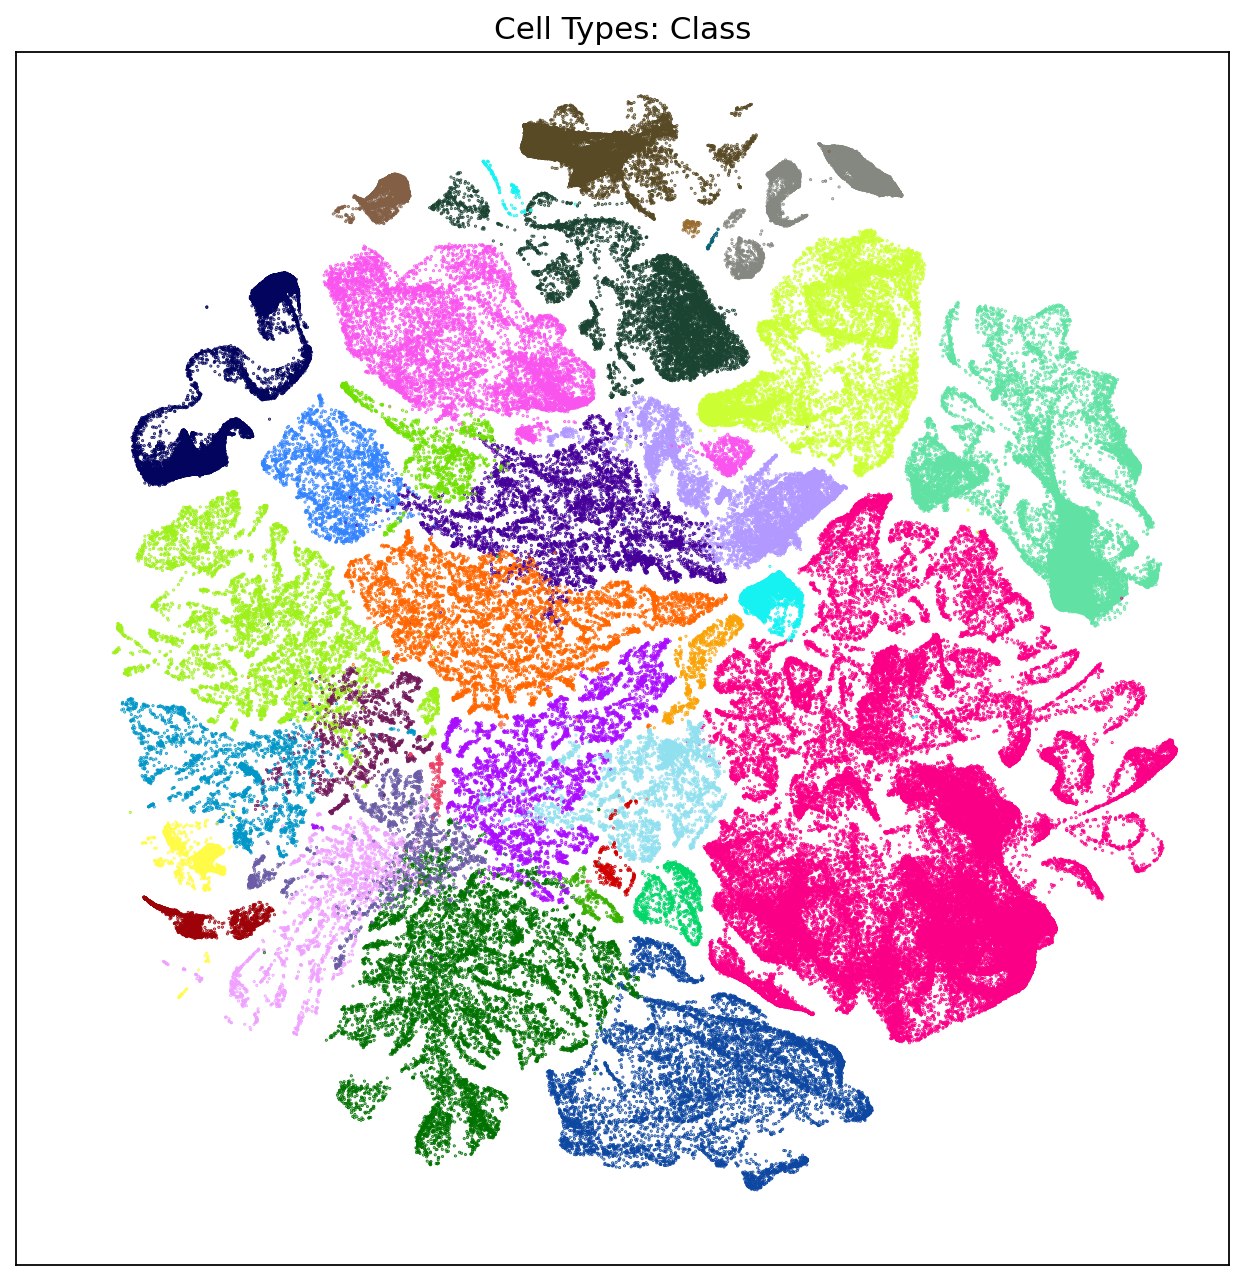

In [45]:
fig, ax = plot_umap(
    cell_subsampled["x"], cell_subsampled["y"], cc=cell_subsampled["class_color"]
)
res = ax.set_title("Cell Types: Class")
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


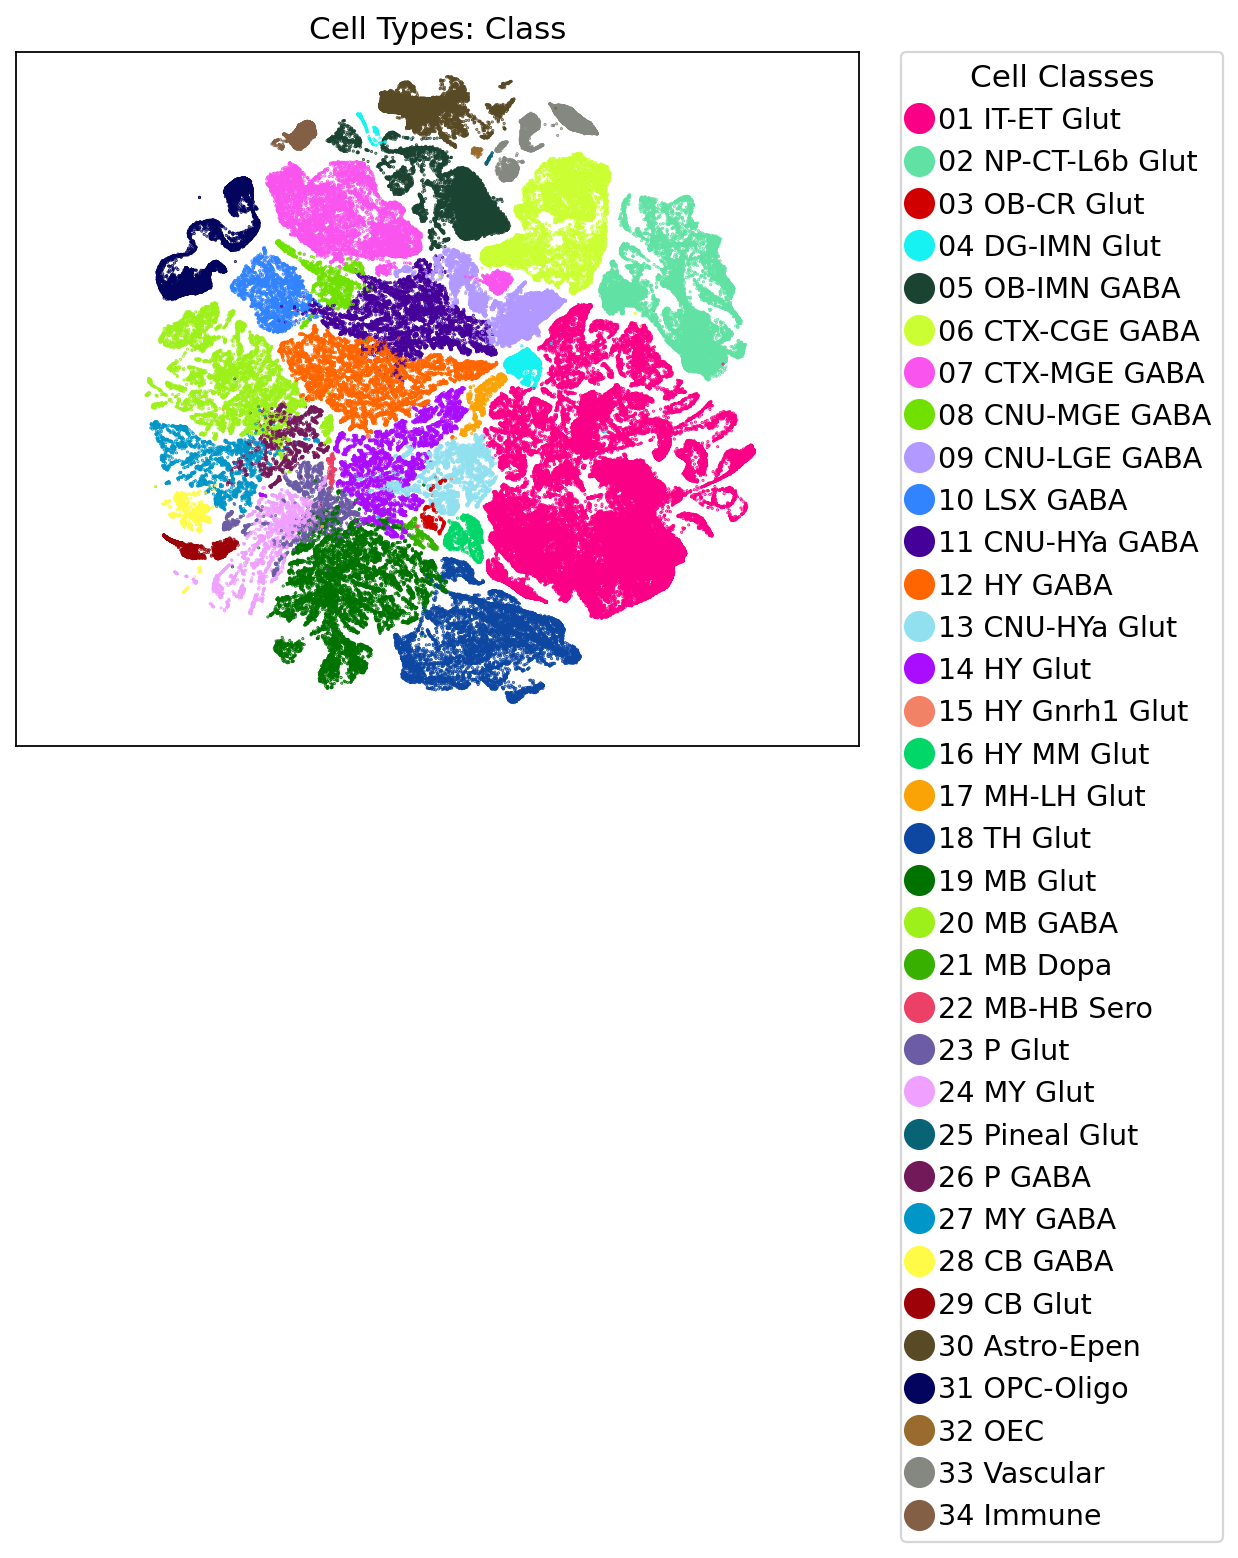

In [46]:
fig, ax = plot_umap(
    cell_subsampled["x"],
    cell_subsampled["y"],
    cc=cell_subsampled["class_color"],
    legend_classes=cell_subsampled["class"],
)
res = ax.set_title("Cell Types: Class")
plt.show()

# Load matrices

## 10Xv2

### Merge adatas

In [47]:
data_dir_10Xv2 = raw_dir / "expression_matrices/WMB-10Xv2/20230630"
data_dir_10Xv2

PosixPath('/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/misc/scRNAseq_ref_ABCAtlas_Yao2023Nature/raw-downloaded/expression_matrices/WMB-10Xv2/20230630')

In [48]:
x = os.listdir(data_dir_10Xv2)
x = [file for file in x if "raw.h5ad" in file]
x

['WMB-10Xv2-HY-raw.h5ad',
 'WMB-10Xv2-TH-raw.h5ad',
 'WMB-10Xv2-Isocortex-1-raw.h5ad',
 'WMB-10Xv2-HPF-raw.h5ad',
 'WMB-10Xv2-Isocortex-3-raw.h5ad',
 'WMB-10Xv2-OLF-raw.h5ad',
 'WMB-10Xv2-CTXsp-raw.h5ad',
 'WMB-10Xv2-Isocortex-4-raw.h5ad',
 'WMB-10Xv2-Isocortex-2-raw.h5ad',
 'WMB-10Xv2-MB-raw.h5ad']

In [49]:
adatas = {p.split(".")[0]: sc.read_h5ad(data_dir_10Xv2 / p) for p in x}

In [50]:
keys = list(adatas.keys())
keys

['WMB-10Xv2-HY-raw',
 'WMB-10Xv2-TH-raw',
 'WMB-10Xv2-Isocortex-1-raw',
 'WMB-10Xv2-HPF-raw',
 'WMB-10Xv2-Isocortex-3-raw',
 'WMB-10Xv2-OLF-raw',
 'WMB-10Xv2-CTXsp-raw',
 'WMB-10Xv2-Isocortex-4-raw',
 'WMB-10Xv2-Isocortex-2-raw',
 'WMB-10Xv2-MB-raw']

In [51]:
for key in adatas.keys():
    adatas[key].obs["key"] = key

In [52]:
for key in adatas.keys():
    adatas[key].obs.index.name = None

In [55]:
adatas[keys[1]].obs.head()

,cell_barcode,library_label,anatomical_division_label,key
CAGGTGCAGGCTAGCA-040_C01,CAGGTGCAGGCTAGCA,L8TX_180815_01_E08,TH,WMB-10Xv2-TH-raw
TGCGCAGGTTGCGCAC-045_C01,TGCGCAGGTTGCGCAC,L8TX_180829_01_C10,TH,WMB-10Xv2-TH-raw
CGATGTATCTTGCCGT-042_B01,CGATGTATCTTGCCGT,L8TX_180829_01_B09,TH,WMB-10Xv2-TH-raw
GACTAACGTCCTCTTG-040_B01,GACTAACGTCCTCTTG,L8TX_180815_01_D08,TH,WMB-10Xv2-TH-raw
GATCGTACAACTGCTA-040_B01,GATCGTACAACTGCTA,L8TX_180815_01_D08,TH,WMB-10Xv2-TH-raw


In [56]:
for key in adatas.keys():
    adatas[key].var["gene_identifier"] = adatas[key].var.index
    adatas[key].var.index = adatas[key].var["gene_symbol"]
    del adatas[key].var["gene_symbol"]

In [57]:
for key in adatas.keys():
    adatas[key].var_names_make_unique()

In [58]:
adatas[key].var.head()

,gene_identifier
gene_symbol,
Xkr4,ENSMUSG00000051951
Gm1992,ENSMUSG00000089699
Gm19938,ENSMUSG00000102331
Gm37381,ENSMUSG00000102343
Rp1,ENSMUSG00000025900


In [59]:
sys.getsizeof(adatas) / 1e9  # GB

2.72e-07

In [61]:
merged_v2 = ad.concat(adatas, axis=0, join="outer", merge="first")

In [62]:
merged_v2

AnnData object with n_obs × n_vars = 1708157 × 32285
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label', 'key'
    var: 'gene_identifier'

In [63]:
merged_v2.obs.index.duplicated().sum()

np.int64(0)

In [64]:
sys.getsizeof(merged_v2) / 1e9  # GB

83.741261558

In [65]:
del adatas
del x
del keys

In [ ]:
merged_v2.write(
    abc_dir / "anndata-objects" / f"{date.today():%Y%m%d}_merged_v2.h5ad.gz",
    compression="gzip",
)

In [ ]:
del merged_v2

### Save/Load

In [8]:
setdate = "20250128"  # raw
adata = sc.read_h5ad(abc_dir / "anndata-objects" / f"{setdate}_merged_v2.h5ad.gz")

In [9]:
adata.obs.drop(
    ["cell_barcode", "library_label", "anatomical_division_label"], axis=1, inplace=True
)

### Add cell metadata
sample and cell type

In [10]:
setdate = "20260923"  # updated cell labels
cell_meta = pd.read_csv(
    abc_dir / f"{setdate}_meta_data_formatted.csv.gz",
    index_col=0,
    dtype=str,
)
cell_meta = cell_meta.astype("category")
cell_meta["cell_type_dea"] = group_cell_types(cell_meta["subclass"]).astype("category")
cell_meta = cell_meta[cell_meta["cell_type_dea"].notna()]
cell_meta.head(2)

,class,subclass,neurotransmitter,library_method,cell_type_dea,donor_id
GCGAGAAGTTAAGGGC-410_B05,01 IT-ET Glut,018 L2 IT PPP-APr Glut,Glut,10Xv3,Neurons-Glut,550850
AATGGCTCAGCTCCTT-411_B06,01 IT-ET Glut,018 L2 IT PPP-APr Glut,Glut,10Xv3,Neurons-Glut,550851


In [11]:
cell_meta.shape

(4042287, 6)

In [12]:
cell_meta["cell_type_dea"].value_counts(normalize=True)

cell_type_dea
Neurons-Glut        0.510588
Neurons-Gaba        0.221154
Oligodendrocytes    0.104818
Astrocytes          0.075139
OPCs                0.030331
ECs                 0.021773
Microglia           0.021332
Pericytes           0.006162
SMCs                0.003615
VLMCs               0.002464
BAMs                0.001400
Ependymal           0.001106
Choroid-Plexus      0.000118
Name: proportion, dtype: float64

In [13]:
adata.obs.head(2)

,key
CGGGTCAGTTAGTGGG-059_E01,WMB-10Xv2-MB-raw
CGCGTTTGTCTAGGTT-067_B01,WMB-10Xv2-MB-raw


In [14]:
adata.obs.shape

(1708157, 1)

In [15]:
adata.obs = adata.obs.join(cell_meta, how="left")

In [16]:
del cell_meta

In [17]:
adata.obs.shape

(1708157, 7)

In [18]:
adata.obs.head(2)

,key,class,subclass,neurotransmitter,library_method,cell_type_dea,donor_id
CGGGTCAGTTAGTGGG-059_E01,WMB-10Xv2-MB-raw,20 MB GABA,205 SC-PAG Lef1 Emx2 Gaba,GABA,10Xv2,Neurons-Gaba,414907
CGCGTTTGTCTAGGTT-067_B01,WMB-10Xv2-MB-raw,19 MB Glut,187 SCsg Pde5a Glut,Glut,10Xv2,Neurons-Glut,423499


Note: Some cells contain basic metadata but no cell type annotation. Possibly low quality? Drop those not in metadata. 

In [19]:
adata.obs.index.duplicated().sum()

np.int64(0)

In [20]:
adata.obs.isnull().sum(axis=0)

key                      0
class                 8285
subclass              8285
neurotransmitter    101486
library_method        8285
cell_type_dea         8285
donor_id              8285
dtype: int64

In [21]:
missing_in_meta = adata.obs["donor_id"].isnull()

In [22]:
adata.obs[missing_in_meta].key.value_counts()

key
WMB-10Xv2-OLF-raw            1580
WMB-10Xv2-Isocortex-1-raw    1277
WMB-10Xv2-Isocortex-4-raw    1256
WMB-10Xv2-HPF-raw            1021
WMB-10Xv2-Isocortex-3-raw     684
WMB-10Xv2-HY-raw              683
WMB-10Xv2-Isocortex-2-raw     680
WMB-10Xv2-TH-raw              668
WMB-10Xv2-CTXsp-raw           325
WMB-10Xv2-MB-raw              111
Name: count, dtype: int64

In [23]:
adata = adata[~missing_in_meta]

In [24]:
adata.shape

(1699872, 32285)

In [25]:
adata.obs.head(2)

,key,class,subclass,neurotransmitter,library_method,cell_type_dea,donor_id
CGGGTCAGTTAGTGGG-059_E01,WMB-10Xv2-MB-raw,20 MB GABA,205 SC-PAG Lef1 Emx2 Gaba,GABA,10Xv2,Neurons-Gaba,414907
CGCGTTTGTCTAGGTT-067_B01,WMB-10Xv2-MB-raw,19 MB Glut,187 SCsg Pde5a Glut,Glut,10Xv2,Neurons-Glut,423499


In [26]:
adata

View of AnnData object with n_obs × n_vars = 1699872 × 32285
    obs: 'key', 'class', 'subclass', 'neurotransmitter', 'library_method', 'cell_type_dea', 'donor_id'
    var: 'gene_identifier'

### Add gene metadata
Contains no additional information

### Export ECs

For additional annotation of EC zonation (separate script)

In [27]:
adata_vascular = adata[
    adata.obs["cell_type_dea"].isin(["Pericytes", "ECs", "VLMCs", "SMCs"])
].copy()

In [28]:
adata_vascular

AnnData object with n_obs × n_vars = 6894 × 32285
    obs: 'key', 'class', 'subclass', 'neurotransmitter', 'library_method', 'cell_type_dea', 'donor_id'
    var: 'gene_identifier'

In [29]:
adata_vascular.write(
    abc_dir
    / "anndata-objects"
    / f"{date.today():%Y%m%d}_merged_v2_vascular_subset.h5ad.gz",
    compression="gzip",
)

In [30]:
del adata_vascular

### Pseudobulking

In [31]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 6911718649 stored elements and shape (1699872, 32285)>

In [32]:
adata.X.max()

np.float32(4303.0)

In [33]:
adata.obs.head(2)

,key,class,subclass,neurotransmitter,library_method,cell_type_dea,donor_id
CGGGTCAGTTAGTGGG-059_E01,WMB-10Xv2-MB-raw,20 MB GABA,205 SC-PAG Lef1 Emx2 Gaba,GABA,10Xv2,Neurons-Gaba,414907
CGCGTTTGTCTAGGTT-067_B01,WMB-10Xv2-MB-raw,19 MB Glut,187 SCsg Pde5a Glut,Glut,10Xv2,Neurons-Glut,423499


In [34]:
adata.obs["cell_type_dea"].value_counts()

cell_type_dea
Neurons-Glut        1273112
Neurons-Gaba         334422
Oligodendrocytes      51796
OPCs                  16146
Astrocytes            12340
Microglia              4760
ECs                    3655
Pericytes              1737
SMCs                    909
VLMCs                   593
Ependymal               259
BAMs                    114
Choroid-Plexus           29
Name: count, dtype: int64

In [35]:
for cell_type in adata.obs["cell_type_dea"].cat.categories:
    unique_donors = len(
        adata[adata.obs["cell_type_dea"] == cell_type].obs["donor_id"].cat.categories
    )
    print(f"{unique_donors} {cell_type}")

95 Astrocytes
27 BAMs
4 Choroid-Plexus
94 ECs
14 Ependymal
93 Microglia
96 Neurons-Gaba
96 Neurons-Glut
93 OPCs
96 Oligodendrocytes
88 Pericytes
77 SMCs
75 VLMCs


In [36]:
combined_values = (
    adata.obs["cell_type_dea"].astype(str) + "_" + adata.obs["donor_id"].astype(str)
)
adata.obs["celltypedea_donorid"] = pd.Categorical(combined_values)
del combined_values

In [37]:
adata.obs["n_cells"] = adata.obs.groupby(["cell_type_dea", "donor_id"])[
    "donor_id"
].transform("count")

In [38]:
adata.obs[:2]

,key,class,subclass,neurotransmitter,library_method,cell_type_dea,donor_id,celltypedea_donorid,n_cells
CGGGTCAGTTAGTGGG-059_E01,WMB-10Xv2-MB-raw,20 MB GABA,205 SC-PAG Lef1 Emx2 Gaba,GABA,10Xv2,Neurons-Gaba,414907,Neurons-Gaba_414907,6103
CGCGTTTGTCTAGGTT-067_B01,WMB-10Xv2-MB-raw,19 MB Glut,187 SCsg Pde5a Glut,Glut,10Xv2,Neurons-Glut,423499,Neurons-Glut_423499,2230


In [39]:
ncells = adata.obs.groupby(["cell_type_dea", "donor_id"])["n_cells"].count()
ncells = pd.DataFrame(ncells)

In [40]:
adata.obs["cell_type_dea"] = (
    adata.obs["cell_type_dea"]
    .astype(str)
    .str.replace(r"[ /]", "_", regex=True)
    .str.replace(r"[+()]", "", regex=True)
)

In [41]:
adata.obs["donor_id"] = adata.obs["donor_id"].astype("category")
adata.obs["cell_type_dea"] = adata.obs["cell_type_dea"].astype("category")
adata.obs["celltypedea_donorid"] = adata.obs["celltypedea_donorid"].astype("category")
adata.obs["n_cells"] = adata.obs["n_cells"].astype(int)

Pseudobulks per cell type and donor with `cellseg_benchmark.dea_utils.pseudobulk_aggregate_and_filter`, keeping cell type-donor groups with at least `min_cells` cells.

In [42]:
obs_to_keep = [
    "cell_type_dea",
    "donor_id",
    "celltypedea_donorid",
    "n_cells",
    "library_method",
]

In [43]:
min_cells = 16
start_total = time()
adata_pb = pseudobulk_cell_types(adata, obs_to_keep, min_cells)
print(f"Total time: {(time() - start_total) / 60:.1f}m")

Processing Astrocytes (1 out of 13)
Processing BAMs (2 out of 13)
Processing Choroid-Plexus (3 out of 13)
Processing ECs (4 out of 13)
Processing Ependymal (5 out of 13)
Processing Microglia (6 out of 13)
Processing Neurons-Gaba (7 out of 13)
Processing Neurons-Glut (8 out of 13)
Processing OPCs (9 out of 13)
Processing Oligodendrocytes (10 out of 13)
Processing Pericytes (11 out of 13)
Processing SMCs (12 out of 13)
Processing VLMCs (13 out of 13)
Total time: 140.6m


In [44]:
adata_pb.obs_names = adata_pb.obs["celltypedea_donorid"]
adata_pb.obs["n_cells"] = adata_pb.obs["n_cells"].astype(int)

In [45]:
adata_pb

AnnData object with n_obs × n_vars = 614 × 32285
    obs: 'cell_type_dea', 'celltypedea_donorid', 'n_cells', 'library_method', 'donor_id', 'batch'

In [46]:
pd.crosstab(adata_pb.obs["cell_type_dea"], adata_pb.obs["batch"])

batch,0,1
cell_type_dea,,
Astrocytes,76,0
BAMs,2,0
Choroid-Plexus,1,0
ECs,61,0
Ependymal,6,0
Microglia,53,0
Neurons-Gaba,96,0
Neurons-Glut,96,0
OPCs,79,0


### Explore Covariates
on PCA

In [47]:
adata_pb.layers["counts"] = adata_pb.X.copy()
adata_pb.layers["log1p_norm"] = adata_pb.X.copy()
sc.pp.normalize_total(adata_pb, target_sum=1e6, layer="log1p_norm")
sc.pp.log1p(adata_pb, layer="log1p_norm")
adata_pb.X = adata_pb.layers["log1p_norm"]

In [48]:
adata_pb.layers

Layers with keys: counts, log1p_norm

In [49]:
adata_pb.obs["lib_size"] = np.sum(adata_pb.layers["counts"], axis=1)
adata_pb.obs["log_lib_size"] = np.log(adata_pb.obs["lib_size"].astype(np.float64))

In [50]:
adata_pb.obs.head(2)

,cell_type_dea,celltypedea_donorid,n_cells,library_method,donor_id,batch,lib_size,log_lib_size
celltypedea_donorid,,,,,,,,
Astrocytes_352353,Astrocytes,Astrocytes_352353,142,10Xv2,352353,0,434153.0,12.981152
Astrocytes_352356,Astrocytes,Astrocytes_352356,174,10Xv2,352356,0,608173.0,13.318215


In [51]:
sc.pp.pca(adata_pb)

In [52]:
adata_pb.X = adata_pb.layers["counts"].copy()

In [53]:
del adata_pb.layers

In [55]:
adata_pb.uns.keys()

odict_keys(['log1p', 'pca'])

In [66]:
adata_pb.obs["cell_type_dea"] = adata_pb.obs["cell_type_dea"].astype("category")
order = [ct for ct in cell_type_colors if ct in adata_pb.obs["cell_type_dea"].unique()]
adata_pb.obs["cell_type_dea"] = pd.Categorical(adata_pb.obs["cell_type_dea"], categories=order)
adata_pb.uns["cell_type_dea_colors"] = [cell_type_colors[ct] for ct in order]

In [68]:
adata_pb

AnnData object with n_obs × n_vars = 614 × 32285
    obs: 'cell_type_dea', 'celltypedea_donorid', 'n_cells', 'library_method', 'donor_id', 'batch', 'lib_size', 'log_lib_size'
    uns: 'log1p', 'pca', 'cell_type_dea_colors', 'library_method_colors', 'batch_colors'
    obsm: 'X_pca'
    varm: 'PCs'

In [69]:
adata_pb.obs["lib_size"] = adata_pb.obs["lib_size"].astype(int)
adata_pb.obs["celltypedea_donorid"] = adata_pb.obs["celltypedea_donorid"].astype(
    "category"
)
adata_pb.obs.index = adata_pb.obs["celltypedea_donorid"]

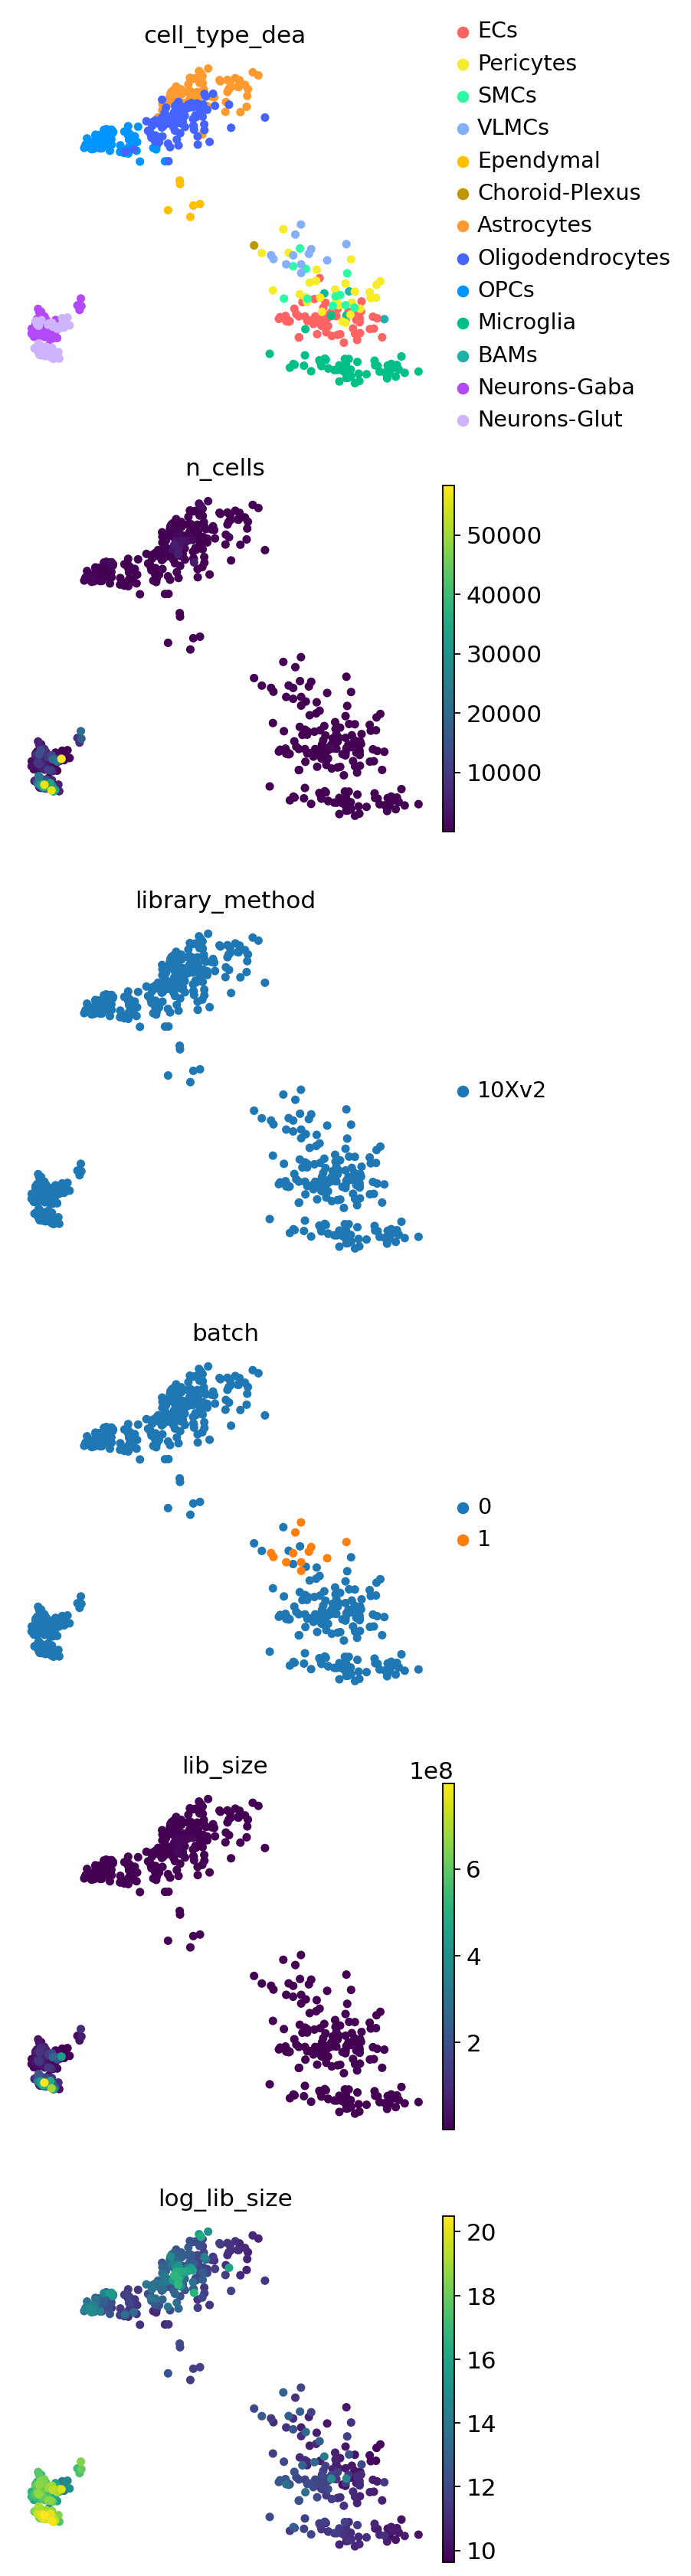

In [71]:
sc.pl.pca(
    adata_pb,
    color=adata_pb.obs.drop(columns=["celltypedea_donorid", "donor_id"]),
    ncols=1,
    size=100,
)

In [72]:
adata_pb.obs.dtypes

cell_type_dea          category
celltypedea_donorid    category
n_cells                   int64
library_method         category
donor_id               category
batch                  category
lib_size                  int64
log_lib_size            float64
dtype: object

In [73]:
adata_pb.X = scipy.sparse.csr_matrix(adata_pb.X, dtype="float32")

In [74]:
adata_pb.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 9415491 stored elements and shape (614, 32285)>

### Save/Load

In [75]:
adata_pb.write(
    abc_dir
    / "anndata-objects"
    / f"{date.today():%Y%m%d}_merged_v2_pseudobulks.h5ad.gz",
    compression="gzip",
)

In [76]:
setdate = "20260925"  # raw counts, pseudobulks, updated cell types
adata = sc.read_h5ad(
    abc_dir / "anndata-objects" / f"{setdate}_merged_v2_pseudobulks.h5ad.gz"
)

In [77]:
adata

AnnData object with n_obs × n_vars = 614 × 32285
    obs: 'cell_type_dea', 'celltypedea_donorid', 'n_cells', 'library_method', 'donor_id', 'batch', 'lib_size', 'log_lib_size'
    uns: 'batch_colors', 'cell_type_dea_colors', 'library_method_colors', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [78]:
adata.X.max()

np.float32(2.1642372e+07)

In [79]:
del adata
del adata_pb

## 10Xv3

### Merge adatas

In [ ]:
data_dir_10Xv3 = raw_dir / "expression_matrices/WMB-10Xv3/20230630"
data_dir_10Xv3

In [9]:
x = os.listdir(data_dir_10Xv3)
x = [file for file in x if "raw.h5ad" in file]
x

['WMB-10Xv3-CB-raw.h5ad',
 'WMB-10Xv3-P-raw.h5ad',
 'WMB-10Xv3-CTXsp-raw.h5ad',
 'WMB-10Xv3-HY-raw.h5ad',
 'WMB-10Xv3-Isocortex-2-raw.h5ad',
 'WMB-10Xv3-MB-raw.h5ad',
 'WMB-10Xv3-PAL-raw.h5ad',
 'WMB-10Xv3-HPF-raw.h5ad',
 'WMB-10Xv3-Isocortex-1-raw.h5ad',
 'WMB-10Xv3-STR-raw.h5ad',
 'WMB-10Xv3-TH-raw.h5ad',
 'WMB-10Xv3-OLF-raw.h5ad',
 'WMB-10Xv3-MY-raw.h5ad']

In [ ]:
adatas = {p.split(".")[0]: sc.read_h5ad(data_dir_10Xv3 / p) for p in x}

In [ ]:
keys = list(adatas.keys())
keys

In [16]:
for key in adatas.keys():
    adatas[key].obs["key"] = key

In [17]:
for key in adatas.keys():
    adatas[key].obs.index.name = None

In [19]:
adatas[keys[1]].obs.head()

,cell_barcode,library_label,anatomical_division_label,key
GCCCGAAGTCAGTTTG-344_C04,GCCCGAAGTCAGTTTG,L8TX_200827_01_E10,CTXsp,WMB-10Xv3-CTXsp-raw
AGGTTACTCGCGCCAA-332_B01,AGGTTACTCGCGCCAA,L8TX_200820_01_D01,CTXsp,WMB-10Xv3-CTXsp-raw
ATGAGGGAGTGTTCCA-332_A01,ATGAGGGAGTGTTCCA,L8TX_200820_01_E02,CTXsp,WMB-10Xv3-CTXsp-raw
CATAGACAGTCTAACC-299_B02,CATAGACAGTCTAACC,L8TX_200723_01_G09,CTXsp,WMB-10Xv3-CTXsp-raw
GAGTTACCATGACGAG-299_A02,GAGTTACCATGACGAG,L8TX_200723_01_F09,CTXsp,WMB-10Xv3-CTXsp-raw


In [20]:
for key in adatas.keys():
    adatas[key].var["gene_identifier"] = adatas[key].var.index
    adatas[key].var.index = adatas[key].var["gene_symbol"]
    del adatas[key].var["gene_symbol"]

In [21]:
for key in adatas.keys():
    adatas[key].var_names_make_unique()

In [22]:
adatas[key].var.head()

,gene_identifier
gene_symbol,
Xkr4,ENSMUSG00000051951
Gm1992,ENSMUSG00000089699
Gm19938,ENSMUSG00000102331
Gm37381,ENSMUSG00000102343
Rp1,ENSMUSG00000025900


In [23]:
sys.getsizeof(adatas) / 1e9  # GB

6.4e-07

In [25]:
merged_v3 = ad.concat(adatas, axis=0, join="outer", merge="first")

In [26]:
merged_v3

AnnData object with n_obs × n_vars = 2349544 × 32285
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label', 'key'
    var: 'gene_identifier'

In [27]:
merged_v3.obs.index.duplicated().sum()

0

In [28]:
sys.getsizeof(merged_v3) / 1e9  # GB

142.113155675

In [29]:
del adatas
del x
del keys

In [30]:
merged_v3.write(
    abc_dir / "anndata-objects" / f"{date.today():%Y%m%d}_merged_v3.h5ad.gz",
    compression="gzip",
)

In [31]:
del merged_v3

### Save/Load

In [8]:
setdate = "20250129"  # raw
adata = sc.read_h5ad(abc_dir / "anndata-objects" / f"{setdate}_merged_v3.h5ad.gz")

In [9]:
adata.obs.drop(
    ["cell_barcode", "library_label", "anatomical_division_label"], axis=1, inplace=True
)

In [10]:
adata

AnnData object with n_obs × n_vars = 2349544 × 32285
    obs: 'key'
    var: 'gene_identifier'

### Add cell metadata
sample and cell type

In [11]:
setdate = "20260923"  # updated cell labels
cell_meta = pd.read_csv(
    abc_dir / f"{setdate}_meta_data_formatted.csv.gz",
    index_col=0,
    dtype=str,
)
cell_meta = cell_meta.astype("category")
cell_meta["cell_type_dea"] = group_cell_types(cell_meta["subclass"]).astype("category")
cell_meta = cell_meta[cell_meta["cell_type_dea"].notna()]
cell_meta.head(2)

,class,subclass,neurotransmitter,library_method,cell_type_dea,donor_id
GCGAGAAGTTAAGGGC-410_B05,01 IT-ET Glut,018 L2 IT PPP-APr Glut,Glut,10Xv3,Neurons-Glut,550850
AATGGCTCAGCTCCTT-411_B06,01 IT-ET Glut,018 L2 IT PPP-APr Glut,Glut,10Xv3,Neurons-Glut,550851


In [12]:
adata.obs.head(2)

,key
TGAGGGACACCAAATC-392_A04,WMB-10Xv3-HY-raw
AACGGGAGTACGTGAG-469_A03,WMB-10Xv3-HY-raw


In [13]:
adata.obs.shape

(2349544, 1)

In [14]:
adata.obs = adata.obs.join(cell_meta, how="left")

In [15]:
adata.obs.shape

(2349544, 7)

In [16]:
adata.obs.head(2)

,key,class,subclass,neurotransmitter,library_method,cell_type_dea,donor_id
TGAGGGACACCAAATC-392_A04,WMB-10Xv3-HY-raw,11 CNU-HYa GABA,079 CEA-BST Six3 Cyp26b1 Gaba,GABA,10Xv3,Neurons-Gaba,546895
AACGGGAGTACGTGAG-469_A03,WMB-10Xv3-HY-raw,11 CNU-HYa GABA,079 CEA-BST Six3 Cyp26b1 Gaba,GABA,10Xv3,Neurons-Gaba,556848


In [17]:
donors = sorted(adata.obs["donor_id"].unique())
len(donors)

223

In [18]:
n_splits = 6
adatas = split_adata(adata, n_splits)

In [19]:
adatas

[View of AnnData object with n_obs × n_vars = 406676 × 32285
     obs: 'key', 'class', 'subclass', 'neurotransmitter', 'library_method', 'cell_type_dea', 'donor_id'
     var: 'gene_identifier',
 View of AnnData object with n_obs × n_vars = 374245 × 32285
     obs: 'key', 'class', 'subclass', 'neurotransmitter', 'library_method', 'cell_type_dea', 'donor_id'
     var: 'gene_identifier',
 View of AnnData object with n_obs × n_vars = 427320 × 32285
     obs: 'key', 'class', 'subclass', 'neurotransmitter', 'library_method', 'cell_type_dea', 'donor_id'
     var: 'gene_identifier',
 View of AnnData object with n_obs × n_vars = 375978 × 32285
     obs: 'key', 'class', 'subclass', 'neurotransmitter', 'library_method', 'cell_type_dea', 'donor_id'
     var: 'gene_identifier',
 View of AnnData object with n_obs × n_vars = 378563 × 32285
     obs: 'key', 'class', 'subclass', 'neurotransmitter', 'library_method', 'cell_type_dea', 'donor_id'
     var: 'gene_identifier',
 View of AnnData object with n

In [20]:
del adata

Note: Some cells contain basic metadata but no cell type annotation. Possibly low quality? Drop those not in metadata. 

In [21]:
for i in range(n_splits):
    print(adatas[i].obs.index.duplicated().sum())

0
0
0
0
0
0


In [22]:
for i in range(n_splits):
    print(i)
    print(adatas[i].obs.isnull().sum(axis=0))

0
key                      0
class                    0
subclass                 0
neurotransmitter    186161
library_method           0
cell_type_dea            0
donor_id                 0
dtype: int64
1
key                      0
class                    0
subclass                 0
neurotransmitter    166840
library_method           0
cell_type_dea            0
donor_id                 0
dtype: int64
2
key                      0
class                    0
subclass                 0
neurotransmitter    198640
library_method           0
cell_type_dea            0
donor_id                 0
dtype: int64
3
key                      0
class                 8816
subclass              8816
neurotransmitter    175150
library_method        8816
cell_type_dea         8816
donor_id              8816
dtype: int64
4
key                      0
class                    0
subclass                 0
neurotransmitter    114936
library_method           0
cell_type_dea            0
donor_id            

In [23]:
for i in range(n_splits):
    print(i)
    missing_in_meta = adatas[i].obs["donor_id"].isnull()
    print(adatas[i].obs[missing_in_meta].key.value_counts())
    adatas[i] = adatas[i][~missing_in_meta].copy()

0
key
WMB-10Xv3-CB-raw             0
WMB-10Xv3-CTXsp-raw          0
WMB-10Xv3-HPF-raw            0
WMB-10Xv3-HY-raw             0
WMB-10Xv3-Isocortex-1-raw    0
WMB-10Xv3-Isocortex-2-raw    0
WMB-10Xv3-MB-raw             0
WMB-10Xv3-MY-raw             0
WMB-10Xv3-OLF-raw            0
WMB-10Xv3-P-raw              0
WMB-10Xv3-PAL-raw            0
WMB-10Xv3-STR-raw            0
WMB-10Xv3-TH-raw             0
Name: count, dtype: int64
1
key
WMB-10Xv3-CB-raw             0
WMB-10Xv3-CTXsp-raw          0
WMB-10Xv3-HPF-raw            0
WMB-10Xv3-HY-raw             0
WMB-10Xv3-Isocortex-1-raw    0
WMB-10Xv3-Isocortex-2-raw    0
WMB-10Xv3-MB-raw             0
WMB-10Xv3-MY-raw             0
WMB-10Xv3-OLF-raw            0
WMB-10Xv3-P-raw              0
WMB-10Xv3-PAL-raw            0
WMB-10Xv3-STR-raw            0
WMB-10Xv3-TH-raw             0
Name: count, dtype: int64
2
key
WMB-10Xv3-CB-raw             0
WMB-10Xv3-CTXsp-raw          0
WMB-10Xv3-HPF-raw            0
WMB-10Xv3-HY-raw             0


In [24]:
adatas

[AnnData object with n_obs × n_vars = 406676 × 32285
     obs: 'key', 'class', 'subclass', 'neurotransmitter', 'library_method', 'cell_type_dea', 'donor_id'
     var: 'gene_identifier',
 AnnData object with n_obs × n_vars = 374245 × 32285
     obs: 'key', 'class', 'subclass', 'neurotransmitter', 'library_method', 'cell_type_dea', 'donor_id'
     var: 'gene_identifier',
 AnnData object with n_obs × n_vars = 427320 × 32285
     obs: 'key', 'class', 'subclass', 'neurotransmitter', 'library_method', 'cell_type_dea', 'donor_id'
     var: 'gene_identifier',
 AnnData object with n_obs × n_vars = 367162 × 32285
     obs: 'key', 'class', 'subclass', 'neurotransmitter', 'library_method', 'cell_type_dea', 'donor_id'
     var: 'gene_identifier',
 AnnData object with n_obs × n_vars = 378563 × 32285
     obs: 'key', 'class', 'subclass', 'neurotransmitter', 'library_method', 'cell_type_dea', 'donor_id'
     var: 'gene_identifier',
 AnnData object with n_obs × n_vars = 386762 × 32285
     obs: 'key', 

In [25]:
del cell_meta

### Add gene metadata
No additional information

### Export ECs

For additional annotation of EC zonation (separate script)

In [26]:
filtered_adatas = {}

In [27]:
for i in range(n_splits):
    filtered_adatas[i] = adatas[i][
        adatas[i].obs["cell_type_dea"].isin(["Pericytes", "ECs", "VLMCs", "SMCs"])
    ].copy()

In [28]:
adata_merged = sc.concat(list(filtered_adatas.values()))

In [29]:
adata_merged

AnnData object with n_obs × n_vars = 130599 × 32285
    obs: 'key', 'class', 'subclass', 'neurotransmitter', 'library_method', 'cell_type_dea', 'donor_id'

In [30]:
adata_merged.obs.cell_type_dea.value_counts()

cell_type_dea
ECs          84356
Pericytes    23170
SMCs         13705
VLMCs         9368
Name: count, dtype: int64

In [31]:
adata_merged.write(
    abc_dir
    / "anndata-objects"
    / f"{date.today():%Y%m%d}_merged_v3_vascular_subset.h5ad.gz",
    compression="gzip",
)

In [32]:
del adata_merged
del filtered_adatas

### Pseudobulking

In [33]:
adatas[i].X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1962988432 stored elements and shape (386762, 32285)>

In [34]:
for i in range(n_splits):
    print(adatas[i].X.max())

16928.0
34575.0
10250.0
11869.0
14814.0
15060.0


In [35]:
adatas[i].obs.head(2)

,key,class,subclass,neurotransmitter,library_method,cell_type_dea,donor_id
TACCTGCAGTTCCTGA-354_A06,WMB-10Xv3-HY-raw,11 CNU-HYa GABA,080 CEA-AAA-BST Six3 Sp9 Gaba,GABA,10Xv3,Neurons-Gaba,540230
AACCTTTGTAACTGCT-354_C06,WMB-10Xv3-HY-raw,11 CNU-HYa GABA,080 CEA-AAA-BST Six3 Sp9 Gaba,GABA,10Xv3,Neurons-Gaba,540230


In [36]:
for i in range(n_splits):
    print(i)
    print(adatas[i].obs["cell_type_dea"].value_counts())

0
cell_type_dea
Neurons-Glut        118837
Neurons-Gaba        102252
Oligodendrocytes     62959
Astrocytes           58633
OPCs                 19193
ECs                  17666
Microglia            14682
Pericytes             4773
SMCs                  2797
VLMCs                 2264
Ependymal             1323
BAMs                  1213
Choroid-Plexus          84
Name: count, dtype: int64
1
cell_type_dea
Neurons-Glut        117060
Neurons-Gaba         90887
Oligodendrocytes     61872
Astrocytes           51751
ECs                  15635
OPCs                 14929
Microglia            13033
Pericytes             3982
SMCs                  2101
VLMCs                 1285
BAMs                   892
Ependymal              737
Choroid-Plexus          81
Name: count, dtype: int64
2
cell_type_dea
Neurons-Glut        136864
Neurons-Gaba         92254
Oligodendrocytes     68780
Astrocytes           62223
OPCs                 22369
Microglia            17942
ECs                  15505
Pericytes

In [37]:
for i in range(n_splits):
    print(i)
    for cell_type in adatas[i].obs["cell_type_dea"].cat.categories:
        unique_donors = len(
            adatas[i][adatas[i].obs["cell_type_dea"] == cell_type]
            .obs["donor_id"]
            .cat.categories
        )
        print(f"{unique_donors} {cell_type}")

0
38 Astrocytes
30 BAMs
5 Choroid-Plexus
38 ECs
22 Ependymal
37 Microglia
38 Neurons-Gaba
38 Neurons-Glut
38 OPCs
38 Oligodendrocytes
36 Pericytes
35 SMCs
36 VLMCs
1
37 Astrocytes
28 BAMs
4 Choroid-Plexus
37 ECs
21 Ependymal
37 Microglia
37 Neurons-Gaba
37 Neurons-Glut
37 OPCs
37 Oligodendrocytes
34 Pericytes
34 SMCs
29 VLMCs
2
37 Astrocytes
30 BAMs
5 Choroid-Plexus
36 ECs
14 Ependymal
36 Microglia
37 Neurons-Gaba
37 Neurons-Glut
37 OPCs
37 Oligodendrocytes
36 Pericytes
31 SMCs
36 VLMCs
3
36 Astrocytes
25 BAMs
5 Choroid-Plexus
35 ECs
19 Ependymal
35 Microglia
36 Neurons-Gaba
36 Neurons-Glut
36 OPCs
36 Oligodendrocytes
35 Pericytes
31 SMCs
32 VLMCs
4
37 Astrocytes
27 BAMs
5 Choroid-Plexus
36 ECs
20 Ependymal
36 Microglia
37 Neurons-Gaba
37 Neurons-Glut
37 OPCs
37 Oligodendrocytes
32 Pericytes
32 SMCs
31 VLMCs
5
37 Astrocytes
27 BAMs
4 Choroid-Plexus
37 ECs
22 Ependymal
36 Microglia
37 Neurons-Gaba
37 Neurons-Glut
37 OPCs
37 Oligodendrocytes
36 Pericytes
30 SMCs
33 VLMCs


In [38]:
for i in range(n_splits):
    adatas[i].obs["n_cells"] = (
        adatas[i]
        .obs.groupby(["cell_type_dea", "donor_id"])["donor_id"]
        .transform("count")
    )

In [39]:
adatas[i].obs[:2]

,key,class,subclass,neurotransmitter,library_method,cell_type_dea,donor_id,n_cells
TACCTGCAGTTCCTGA-354_A06,WMB-10Xv3-HY-raw,11 CNU-HYa GABA,080 CEA-AAA-BST Six3 Sp9 Gaba,GABA,10Xv3,Neurons-Gaba,540230,5628
AACCTTTGTAACTGCT-354_C06,WMB-10Xv3-HY-raw,11 CNU-HYa GABA,080 CEA-AAA-BST Six3 Sp9 Gaba,GABA,10Xv3,Neurons-Gaba,540230,5628


In [40]:
ncells = adatas[i].obs.groupby(["cell_type_dea", "donor_id"])["n_cells"].count()
ncells = pd.DataFrame(ncells)

In [41]:
ncells

n_cells
cell_type_dea donor_id         
Astrocytes    426001         12
              450095          8
              457909         88
              464328         42
              468425         80
...                         ...
VLMCs         565914         32
              574606         82
              574607         26
              604611          1
              621073         40

[481 rows x 1 columns]

In [42]:
for i in range(n_splits):
    adatas[i].obs["cell_type_dea"] = (
        adatas[i]
        .obs["cell_type_dea"]
        .astype(str)
        .str.replace(r"[ /]", "_", regex=True)
        .str.replace(r"[+()]", "", regex=True)
    )

In [43]:
for i in range(n_splits):
    adatas[i].obs["donor_id"] = adatas[i].obs["donor_id"].astype("category")
    adatas[i].obs["cell_type_dea"] = adatas[i].obs["cell_type_dea"].astype("category")
    adatas[i].obs["n_cells"] = adatas[i].obs["n_cells"].astype(int)

In [44]:
obs_to_keep = [
    "cell_type_dea",
    "donor_id",
    "n_cells",
    "library_method",
]

In [45]:
min_cells = 16

In [49]:
start_total = time()
for i, adata_split in enumerate(adatas):
    print(f"Processing split {i + 1} out of {len(adatas)}...")
    adata_pb_split = pseudobulk_cell_types(adata_split, obs_to_keep, min_cells)
    adata_pb_split.X = scipy.sparse.csr_matrix(adata_pb_split.X, dtype="float32")
    adata_pb_split.obs["n_cells"] = adata_pb_split.obs["n_cells"].astype(int)
    output_path = (
        abc_dir
        / "anndata-objects"
        / f"{date.today():%Y%m%d}_merged_v3_pseudobulks_split_{i}.h5ad.gz"
    )
    adata_pb_split.write(output_path, compression="gzip")
    del adata_pb_split
print(f"Total time: {(time() - start_total) / 60:.1f}m")

Processing split 4 out of 6...
Processing Astrocytes (1 out of 13)
Processing BAMs (2 out of 13)


	All donors below min_cells=16 in this group; nothing to aggregate.


Processing Choroid-Plexus (3 out of 13)
Processing ECs (4 out of 13)
Processing Ependymal (5 out of 13)
Processing Microglia (6 out of 13)
Processing Neurons-Gaba (7 out of 13)
Processing Neurons-Glut (8 out of 13)
Processing OPCs (9 out of 13)
Processing Oligodendrocytes (10 out of 13)
Processing Pericytes (11 out of 13)
Processing SMCs (12 out of 13)
Processing VLMCs (13 out of 13)
Processing split 5 out of 6...
Processing Astrocytes (1 out of 13)
Processing BAMs (2 out of 13)
Processing Choroid-Plexus (3 out of 13)
Processing ECs (4 out of 13)
Processing Ependymal (5 out of 13)
Processing Microglia (6 out of 13)
Processing Neurons-Gaba (7 out of 13)
Processing Neurons-Glut (8 out of 13)
Processing OPCs (9 out of 13)
Processing Oligodendrocytes (10 out of 13)
Processing Pericytes (11 out of 13)
Processing SMCs (12 out of 13)
Processing VLMCs (13 out of 13)
Processing split 6 out of 6...
Processing Astrocytes (1 out of 13)
Processing BAMs (2 out of 13)
Processing Choroid-Plexus (3 out

In [50]:
del adatas

In [51]:
setdate = "20260925"  # updated cell labels
files = sorted(
    (abc_dir / "anndata-objects").glob(
        f"{setdate}_merged_v3_pseudobulks_split_*.h5ad.gz"
    )
)

In [52]:
files

[PosixPath('/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/misc/scRNAseq_ref_ABCAtlas_Yao2023Nature/anndata-objects/20260925_merged_v3_pseudobulks_split_0.h5ad.gz'),
 PosixPath('/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/misc/scRNAseq_ref_ABCAtlas_Yao2023Nature/anndata-objects/20260925_merged_v3_pseudobulks_split_1.h5ad.gz'),
 PosixPath('/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/misc/scRNAseq_ref_ABCAtlas_Yao2023Nature/anndata-objects/20260925_merged_v3_pseudobulks_split_2.h5ad.gz'),
 PosixPath('/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/misc/scRNAseq_ref_ABCAtlas_Yao2023Nature/anndata-objects/20260925_merged_v3_pseudobulks_split_3.h5ad.gz'),
 PosixPath('/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/misc/scRNAseq_ref_ABCAtlas_Yao2023Nature/anndata-objects/20260925_merged_v3_pseudobulks_split_4.h5ad.gz'),
 PosixPath('/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/misc/scRNAseq_ref_ABCAtlas_Yao2023Nature/anndata-objects/20260925_mer

In [53]:
adata_merged = sc.concat([sc.read_h5ad(f) for f in files])

In [54]:
adata_merged

AnnData object with n_obs × n_vars = 1826 × 32285
    obs: 'cell_type_dea', 'n_cells', 'library_method', 'donor_id', 'batch'

In [55]:
len(adata_merged.obs["donor_id"].unique())

222

In [56]:
adata_merged.X = scipy.sparse.csr_matrix(adata_merged.X, dtype="float32")

In [57]:
adata_merged.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 33921754 stored elements and shape (1826, 32285)>

In [58]:
adata_merged.X.max()

np.float32(1.3351517e+07)

In [59]:
adata_merged.obs.dtypes

cell_type_dea     category
n_cells              int64
library_method    category
donor_id          category
batch             category
dtype: object

### Save/Load

In [60]:
adata_merged.write(
    abc_dir / "anndata-objects" / f"{date.today():%Y%m%d}_merged_v3_pseudobulks_temp.h5ad.gz",
    compression="gzip"
)

In [61]:
setdate = "20260925"  # raw temp, updated cell labels
adata_merged = sc.read_h5ad(
    abc_dir / "anndata-objects" / f"{setdate}_merged_v3_pseudobulks_temp.h5ad.gz"
)

In [62]:
adata_merged

AnnData object with n_obs × n_vars = 1826 × 32285
    obs: 'cell_type_dea', 'n_cells', 'library_method', 'donor_id', 'batch'

In [64]:
! rm "$abc_dir"/anndata-objects/"$setdate"_merged_v3_pseudobulks_split_[0-9]*.h5ad.gz

In [65]:
adata_pb = adata_merged.copy()

In [66]:
del adata_merged

In [67]:
adata_pb.obs["celltypedea_donorid"] = adata_pb.obs.apply(
    lambda row: f"{row['cell_type_dea']}_{row['donor_id']}", axis=1
)
adata_pb.obs["celltypedea_donorid"] = adata_pb.obs["celltypedea_donorid"].astype(
    "category"
)

In [68]:
adata_pb.obs_names = adata_pb.obs["celltypedea_donorid"]
adata_pb.obs["n_cells"] = adata_pb.obs["n_cells"].astype(int)

In [69]:
adata_pb

AnnData object with n_obs × n_vars = 1826 × 32285
    obs: 'cell_type_dea', 'n_cells', 'library_method', 'donor_id', 'batch', 'celltypedea_donorid'

In [70]:
pd.crosstab(adata_pb.obs["cell_type_dea"], adata_pb.obs["batch"])

batch,0,1
cell_type_dea,,
Astrocytes,208,0
BAMs,93,0
Choroid-Plexus,7,0
ECs,151,0
Ependymal,32,0
Microglia,133,0
Neurons-Gaba,221,0
Neurons-Glut,221,0
OPCs,217,0


### Explore Covariates
on PCA

In [71]:
adata_pb.layers["counts"] = adata_pb.X.copy()
adata_pb.layers["log1p_norm"] = adata_pb.X.copy()
sc.pp.normalize_total(adata_pb, target_sum=1e6, layer="log1p_norm")
sc.pp.log1p(adata_pb, layer="log1p_norm")
adata_pb.X = adata_pb.layers["log1p_norm"]

In [72]:
adata_pb.layers

Layers with keys: counts, log1p_norm

In [73]:
adata_pb.X.max()

np.float32(11.94506)

In [74]:
adata_pb.obs["lib_size"] = np.sum(adata_pb.layers["counts"], axis=1)
adata_pb.obs["log_lib_size"] = np.log(adata_pb.obs["lib_size"].astype(np.float64))

In [75]:
adata_pb.obs["cell_type_dea"] = adata_pb.obs["cell_type_dea"].astype("category")
order = [ct for ct in cell_type_colors if ct in adata_pb.obs["cell_type_dea"].unique()]
adata_pb.obs["cell_type_dea"] = pd.Categorical(adata_pb.obs["cell_type_dea"], categories=order)
adata_pb.uns["cell_type_dea_colors"] = [cell_type_colors[ct] for ct in order]

In [76]:
adata_pb.obs.head(2)

,cell_type_dea,n_cells,library_method,donor_id,batch,celltypedea_donorid,lib_size,log_lib_size
celltypedea_donorid,,,,,,,,
Astrocytes_464327,Astrocytes,151,10Xv3,464327,0,Astrocytes_464327,978639.0,13.793918
Astrocytes_473085,Astrocytes,62,10Xv3,473085,0,Astrocytes_473085,507223.0,13.136706


In [77]:
sc.pp.pca(adata_pb)

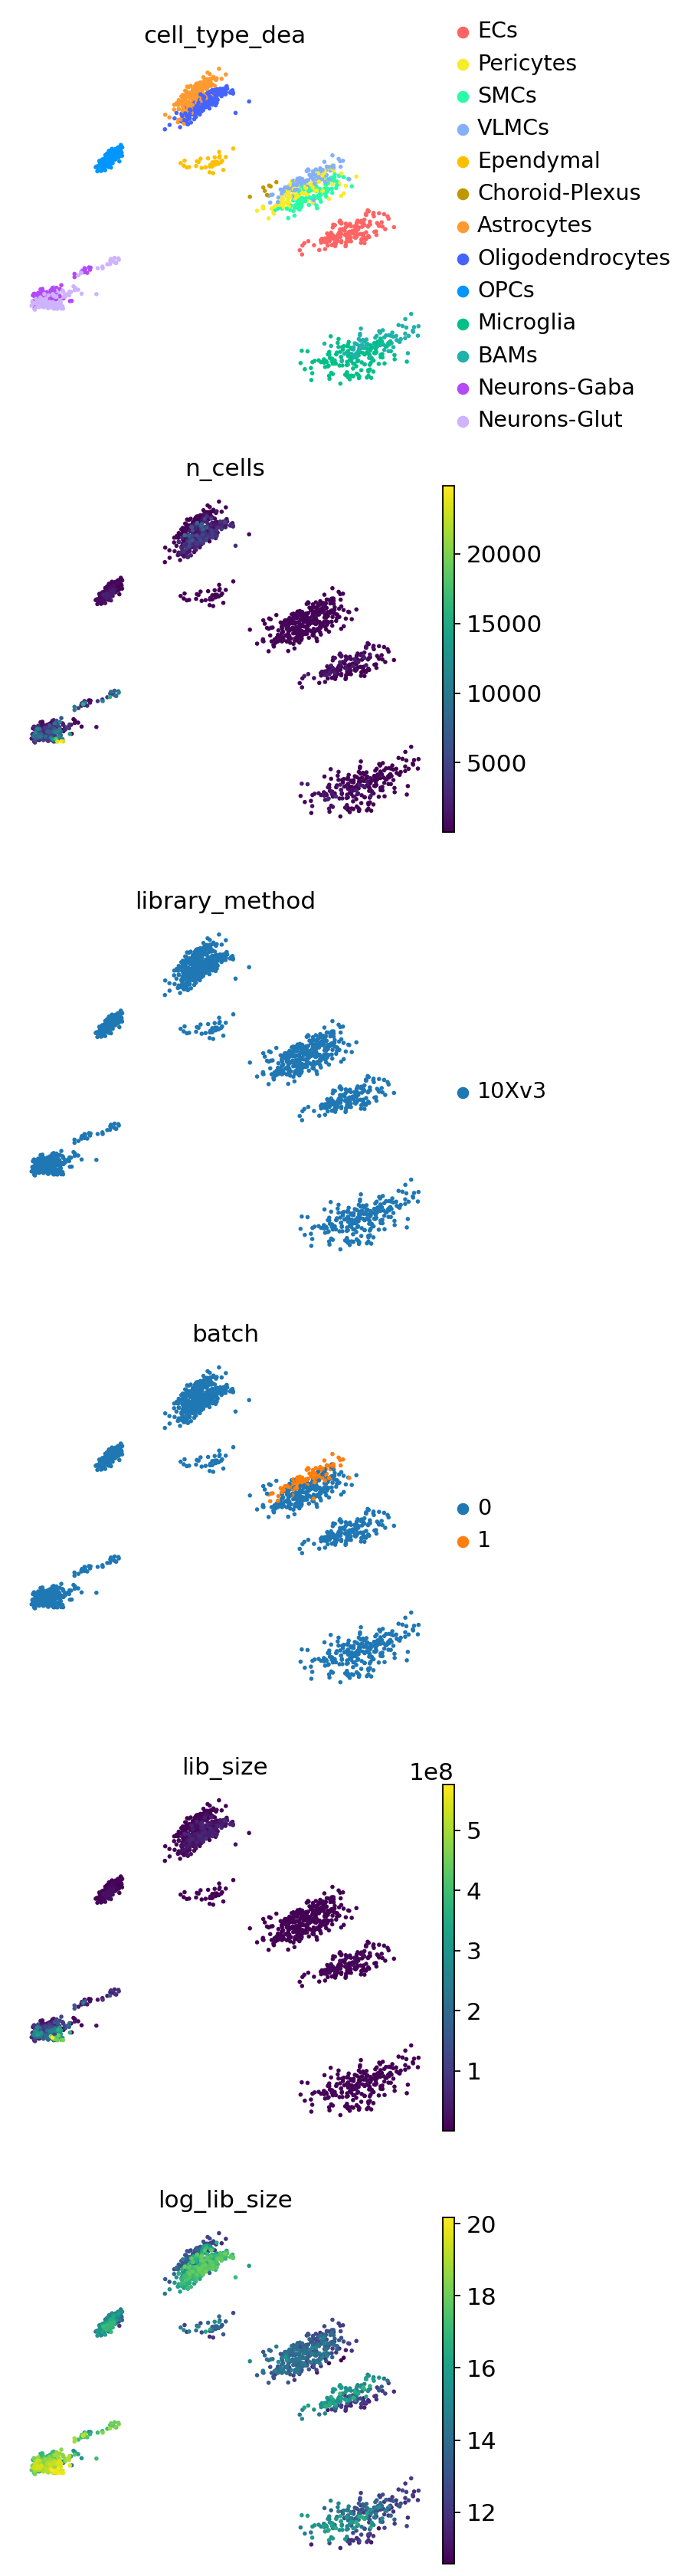

In [87]:
sc.pl.pca(
    adata_pb,
    color=adata_pb.obs.drop(columns=["celltypedea_donorid", "donor_id"]),
    ncols=1,
    size=25,
)

In [79]:
adata_pb.X = adata_pb.layers["counts"].copy()

In [80]:
del adata_pb.layers

In [81]:
adata_pb

AnnData object with n_obs × n_vars = 1826 × 32285
    obs: 'cell_type_dea', 'n_cells', 'library_method', 'donor_id', 'batch', 'celltypedea_donorid', 'lib_size', 'log_lib_size'
    uns: 'log1p', 'cell_type_dea_colors', 'pca', 'library_method_colors', 'batch_colors'
    obsm: 'X_pca'
    varm: 'PCs'

In [82]:
adata_pb.X.max()

np.float32(1.3351517e+07)

In [83]:
adata_pb.obs["lib_size"] = adata_pb.obs["lib_size"].astype(int)
adata_pb.obs["celltypedea_donorid"] = adata_pb.obs["celltypedea_donorid"].astype(
    "category"
)
adata_pb.obs.index = adata_pb.obs["celltypedea_donorid"]

In [84]:
adata_pb.obs.dtypes

cell_type_dea          category
n_cells                   int64
library_method         category
donor_id               category
batch                  category
celltypedea_donorid    category
lib_size                  int64
log_lib_size            float64
dtype: object

### Save/Load

In [88]:
adata_pb.write(
    abc_dir
    / "anndata-objects"
    / f"{date.today():%Y%m%d}_merged_v3_pseudobulks.h5ad.gz",
    compression="gzip",
)

In [89]:
setdate = "20260925"  # raw counts, pseudobulks, updated cell labels
adata = sc.read_h5ad(
    abc_dir / "anndata-objects" / f"{setdate}_merged_v3_pseudobulks.h5ad.gz"
)

In [90]:
adata

AnnData object with n_obs × n_vars = 1826 × 32285
    obs: 'cell_type_dea', 'n_cells', 'library_method', 'donor_id', 'batch', 'celltypedea_donorid', 'lib_size', 'log_lib_size'
    uns: 'batch_colors', 'cell_type_dea_colors', 'library_method_colors', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [91]:
adata.X.max()

np.float32(1.3351517e+07)

# TBC HERE

## 10XMulti

Single file only

In [8]:
data_dir_10XMulti = raw_dir / "expression_matrices/WMB-10XMulti/20230830"
data_dir_10XMulti

PosixPath('/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/misc/scRNAseq_ref_ABCAtlas_Yao2023Nature/raw-downloaded/expression_matrices/WMB-10XMulti/20230830')

In [9]:
x = os.listdir(data_dir_10XMulti)
x = [file for file in x if "raw.h5ad" in file]
x

['WMB-10XMulti-raw.h5ad']

In [10]:
adata_10XMulti = sc.read_h5ad(data_dir_10XMulti / x[0])

In [11]:
adata_10XMulti

AnnData object with n_obs × n_vars = 1687 × 32285
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label'
    var: 'gene_symbol'
    uns: 'normalization', 'parent', 'parent_layer', 'parent_rows'

In [12]:
key = "WMB-10XMulti-raw"

In [13]:
adata_10XMulti.obs["key"] = key

In [14]:
adata_10XMulti.obs.index.name = None

In [15]:
adata_10XMulti.obs.head()

,cell_barcode,library_label,anatomical_division_label,key
AACATCATCAGCCAAT-1143_A05,AACATCATCAGCCAAT,L8XR_220317_03_H06,CB,WMB-10XMulti-raw
AACTAGCTCCGTTAAA-1143_A05,AACTAGCTCCGTTAAA,L8XR_220317_03_H06,CB,WMB-10XMulti-raw
AACTGTTCAGCAGGTA-1143_A05,AACTGTTCAGCAGGTA,L8XR_220317_03_H06,CB,WMB-10XMulti-raw
AAGTTTGTCATAACTG-1143_A05,AAGTTTGTCATAACTG,L8XR_220317_03_H06,CB,WMB-10XMulti-raw
AATTTGGTCAAACCGT-1143_A05,AATTTGGTCAAACCGT,L8XR_220317_03_H06,CB,WMB-10XMulti-raw


In [16]:
adata_10XMulti.var["gene_identifier"] = adata_10XMulti.var.index.astype("str")
adata_10XMulti.var.index = adata_10XMulti.var["gene_symbol"].astype("str")
del adata_10XMulti.var["gene_symbol"]

In [17]:
adata_10XMulti.var_names_make_unique()

In [18]:
adata_10XMulti.var.head()

,gene_identifier
gene_symbol,
Xkr4,ENSMUSG00000051951
Gm1992,ENSMUSG00000089699
Gm19938,ENSMUSG00000102331
Gm37381,ENSMUSG00000102343
Rp1,ENSMUSG00000025900


In [19]:
[gene for gene in adata_10XMulti.var_names if "Ptp4a1" in gene]

['Ptp4a1', 'Ptp4a1-1']

In [20]:
adata_10XMulti.var.dtypes

gene_identifier    object
dtype: object

In [21]:
adata_10XMulti.obs.index.duplicated().sum()

np.int64(0)

In [22]:
sys.getsizeof(adata_10XMulti) / 1e9  # GB

0.133167767

In [23]:
adata = adata_10XMulti.copy()

In [24]:
del adata_10XMulti

### Add cell metadata
sample and cell type

In [25]:
setdate = "20260923"  # updated cell labels
cell_meta = pd.read_csv(
    abc_dir / f"{setdate}_meta_data_formatted.csv.gz",
    index_col=0,
    dtype=str,
)
cell_meta = cell_meta.astype("category")
cell_meta["cell_type_dea"] = group_cell_types(cell_meta["subclass"]).astype("category")
cell_meta = cell_meta[cell_meta["cell_type_dea"].notna()]
cell_meta.head(2)

,class,subclass,neurotransmitter,library_method,cell_type_dea,donor_id
GCGAGAAGTTAAGGGC-410_B05,01 IT-ET Glut,018 L2 IT PPP-APr Glut,Glut,10Xv3,Neurons-Glut,550850
AATGGCTCAGCTCCTT-411_B06,01 IT-ET Glut,018 L2 IT PPP-APr Glut,Glut,10Xv3,Neurons-Glut,550851


In [26]:
adata.obs.head(2)

,cell_barcode,library_label,anatomical_division_label,key
AACATCATCAGCCAAT-1143_A05,AACATCATCAGCCAAT,L8XR_220317_03_H06,CB,WMB-10XMulti-raw
AACTAGCTCCGTTAAA-1143_A05,AACTAGCTCCGTTAAA,L8XR_220317_03_H06,CB,WMB-10XMulti-raw


In [27]:
adata.obs.shape

(1687, 4)

In [28]:
adata.obs = adata.obs.join(cell_meta, how="left")

In [29]:
adata.obs.shape

(1687, 10)

In [30]:
adata.obs.head(2)

,cell_barcode,library_label,anatomical_division_label,key,class,subclass,neurotransmitter,library_method,cell_type_dea,donor_id
AACATCATCAGCCAAT-1143_A05,AACATCATCAGCCAAT,L8XR_220317_03_H06,CB,WMB-10XMulti-raw,24 MY Glut,254 VCO Mafa Meis2 Glut,Glut,10xRSeq_Mult,Neurons-Glut,621255
AACTAGCTCCGTTAAA-1143_A05,AACTAGCTCCGTTAAA,L8XR_220317_03_H06,CB,WMB-10XMulti-raw,24 MY Glut,261 HB Calcb Chol,Chol,10xRSeq_Mult,Neurons-Gaba,621255


Note: Some cells contain basic metadata but no cell type annotation. Possibly low quality? Drop those not in metadata. 

In [31]:
adata.obs.index.duplicated().sum()

np.int64(0)

In [32]:
adata.obs.isnull().sum(axis=0)

cell_barcode                 0
library_label                0
anatomical_division_label    0
key                          0
class                        0
subclass                     0
neurotransmitter             0
library_method               0
cell_type_dea                0
donor_id                     0
dtype: int64

In [33]:
missing_in_meta = adata.obs["donor_id"].isnull()

In [34]:
adata.obs[missing_in_meta].key.value_counts()

Series([], Name: count, dtype: int64)

In [35]:
adata = adata[~missing_in_meta]

In [36]:
adata.shape

(1687, 32285)

In [37]:
adata.obs.head(2)

,cell_barcode,library_label,anatomical_division_label,key,class,subclass,neurotransmitter,library_method,cell_type_dea,donor_id
AACATCATCAGCCAAT-1143_A05,AACATCATCAGCCAAT,L8XR_220317_03_H06,CB,WMB-10XMulti-raw,24 MY Glut,254 VCO Mafa Meis2 Glut,Glut,10xRSeq_Mult,Neurons-Glut,621255
AACTAGCTCCGTTAAA-1143_A05,AACTAGCTCCGTTAAA,L8XR_220317_03_H06,CB,WMB-10XMulti-raw,24 MY Glut,261 HB Calcb Chol,Chol,10xRSeq_Mult,Neurons-Gaba,621255


In [38]:
adata

View of AnnData object with n_obs × n_vars = 1687 × 32285
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label', 'key', 'class', 'subclass', 'neurotransmitter', 'library_method', 'cell_type_dea', 'donor_id'
    var: 'gene_identifier'
    uns: 'normalization', 'parent', 'parent_layer', 'parent_rows'

In [39]:
del cell_meta

### Add gene metadata
No additional information

### Export ECs

For additional annotation of EC zonation (separate script)

In [40]:
adata_vascular = adata[
    adata.obs["cell_type_dea"].isin(["Pericytes", "ECs", "VLMCs", "SMCs"])
].copy()

In [41]:
adata_vascular

AnnData object with n_obs × n_vars = 0 × 32285
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label', 'key', 'class', 'subclass', 'neurotransmitter', 'library_method', 'cell_type_dea', 'donor_id'
    var: 'gene_identifier'
    uns: 'normalization', 'parent', 'parent_layer', 'parent_rows'

Note: No vascular cells

### Pseudobulking

In [42]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10725202 stored elements and shape (1687, 32285)>

In [43]:
adata.X.max()

np.float64(11779.0)

In [44]:
adata.obs.head(2)

,cell_barcode,library_label,anatomical_division_label,key,class,subclass,neurotransmitter,library_method,cell_type_dea,donor_id
AACATCATCAGCCAAT-1143_A05,AACATCATCAGCCAAT,L8XR_220317_03_H06,CB,WMB-10XMulti-raw,24 MY Glut,254 VCO Mafa Meis2 Glut,Glut,10xRSeq_Mult,Neurons-Glut,621255
AACTAGCTCCGTTAAA-1143_A05,AACTAGCTCCGTTAAA,L8XR_220317_03_H06,CB,WMB-10XMulti-raw,24 MY Glut,261 HB Calcb Chol,Chol,10xRSeq_Mult,Neurons-Gaba,621255


In [45]:
adata.obs["cell_type_dea"].value_counts()

cell_type_dea
Neurons-Gaba    1034
Neurons-Glut     653
Name: count, dtype: int64

In [46]:
for cell_type in adata.obs["cell_type_dea"].cat.categories:
    unique_donors = len(
        adata[adata.obs["cell_type_dea"] == cell_type].obs["donor_id"].cat.categories
    )
    print(f"{unique_donors} {cell_type}")

25 Neurons-Gaba
19 Neurons-Glut


In [47]:
adata.obs["celltypedea_donorid"] = adata.obs.apply(
    lambda row: f"{row['cell_type_dea']}_{row['donor_id']}", axis=1
)

In [48]:
adata.obs["n_cells"] = adata.obs.groupby(["cell_type_dea", "donor_id"])[
    "donor_id"
].transform("count")

In [49]:
adata.obs[:2]

,cell_barcode,library_label,anatomical_division_label,key,class,subclass,neurotransmitter,library_method,cell_type_dea,donor_id,celltypedea_donorid,n_cells
AACATCATCAGCCAAT-1143_A05,AACATCATCAGCCAAT,L8XR_220317_03_H06,CB,WMB-10XMulti-raw,24 MY Glut,254 VCO Mafa Meis2 Glut,Glut,10xRSeq_Mult,Neurons-Glut,621255,Neurons-Glut_621255,6
AACTAGCTCCGTTAAA-1143_A05,AACTAGCTCCGTTAAA,L8XR_220317_03_H06,CB,WMB-10XMulti-raw,24 MY Glut,261 HB Calcb Chol,Chol,10xRSeq_Mult,Neurons-Gaba,621255,Neurons-Gaba_621255,61


In [50]:
ncells = adata.obs.groupby(["cell_type_dea", "donor_id"])["n_cells"].count()
ncells = pd.DataFrame(ncells)

In [51]:
adata.obs["cell_type_dea"] = (
    adata.obs["cell_type_dea"]
    .astype(str)
    .str.replace(r"[ /]", "_", regex=True)
    .str.replace(r"[+()]", "", regex=True)
)

In [52]:
adata.obs["donor_id"] = adata.obs["donor_id"].astype("category")
adata.obs["cell_type_dea"] = adata.obs["cell_type_dea"].astype("category")
adata.obs["celltypedea_donorid"] = adata.obs["celltypedea_donorid"].astype("category")
adata.obs["n_cells"] = adata.obs["n_cells"].astype(int)

In [53]:
obs_to_keep = [
    "cell_type_dea",
    "donor_id",
    "celltypedea_donorid",
    "n_cells",
    "library_method",
]

In [54]:
min_cells = 16
adata_pb = pseudobulk_cell_types(adata, obs_to_keep, min_cells)

Processing Neurons-Gaba (1 out of 2)
Processing Neurons-Glut (2 out of 2)


In [55]:
adata_pb.obs_names = adata_pb.obs["celltypedea_donorid"]
adata_pb.obs["n_cells"] = adata_pb.obs["n_cells"].astype(int)

In [56]:
adata_pb

AnnData object with n_obs × n_vars = 22 × 32285
    obs: 'cell_type_dea', 'celltypedea_donorid', 'n_cells', 'library_method', 'donor_id', 'batch'

In [57]:
adata_pb.X.max()

np.float64(355105.0)

In [58]:
pd.crosstab(adata_pb.obs["cell_type_dea"], adata_pb.obs["batch"])

batch,0,1
cell_type_dea,,
Neurons-Gaba,15,0
Neurons-Glut,0,7


### Explore Covariates
on PCA

In [59]:
adata_pb.layers["counts"] = adata_pb.X.copy()
adata_pb.layers["log1p_norm"] = adata_pb.X.copy()
sc.pp.normalize_total(adata_pb, target_sum=1e6, layer="log1p_norm")
sc.pp.log1p(adata_pb, layer="log1p_norm")
adata_pb.X = adata_pb.layers["log1p_norm"]

In [60]:
adata_pb.layers

Layers with keys: counts, log1p_norm

In [61]:
adata_pb.layers["log1p_norm"].max()

np.float64(11.169166156468068)

In [62]:
adata_pb.layers["counts"].max()

np.float64(355105.0)

In [63]:
adata_pb.obs["lib_size"] = np.sum(adata_pb.layers["counts"], axis=1)
adata_pb.obs["log_lib_size"] = np.log(adata_pb.obs["lib_size"].astype(np.float64))

In [64]:
adata_pb.obs.head(2)

,cell_type_dea,celltypedea_donorid,n_cells,library_method,donor_id,batch,lib_size,log_lib_size
celltypedea_donorid,,,,,,,,
Neurons-Gaba_580195,Neurons-Gaba,Neurons-Gaba_580195,28,10xRSeq_Mult,580195,0,357367.0,12.786519
Neurons-Gaba_614000,Neurons-Gaba,Neurons-Gaba_614000,62,10xRSeq_Mult,614000,0,3660926.0,15.113227


In [65]:
sc.pp.pca(adata_pb)

In [66]:
adata_pb.obs["cell_type_dea"] = adata_pb.obs["cell_type_dea"].astype("category")
order = [ct for ct in cell_type_colors if ct in adata_pb.obs["cell_type_dea"].unique()]
adata_pb.obs["cell_type_dea"] = pd.Categorical(adata_pb.obs["cell_type_dea"], categories=order)
adata_pb.uns["cell_type_dea_colors"] = [cell_type_colors[ct] for ct in order]

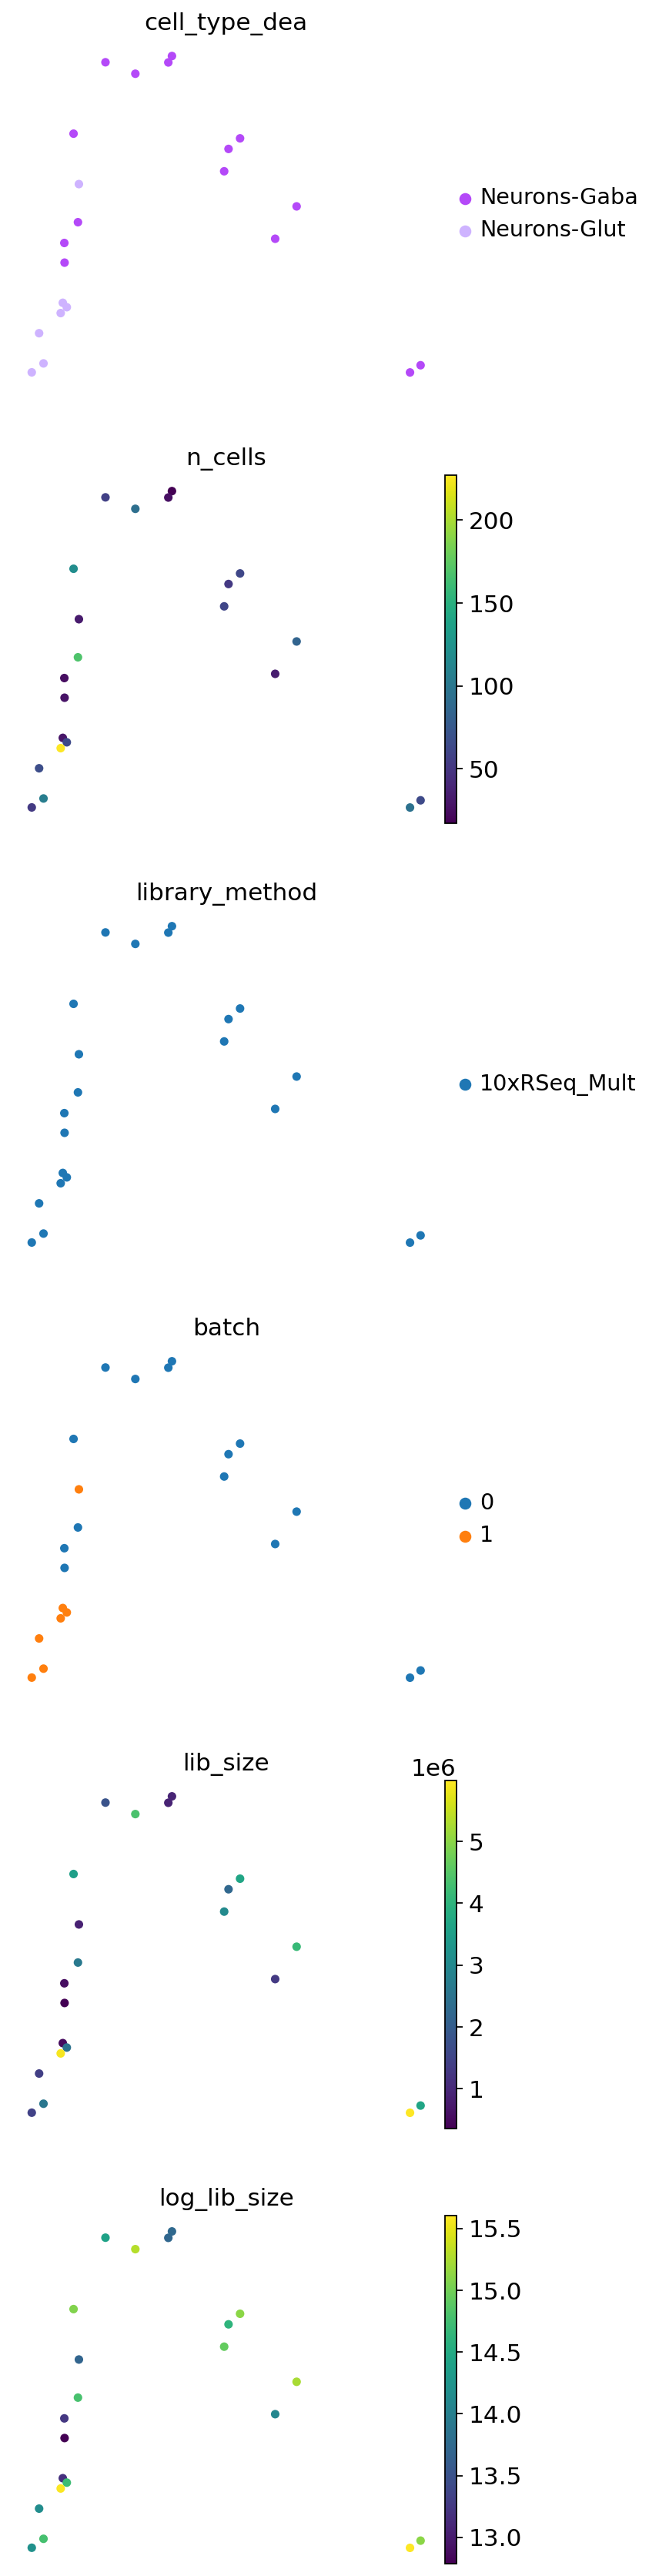

In [67]:
sc.pl.pca(
    adata_pb,
    color=adata_pb.obs.drop(columns=["celltypedea_donorid", "donor_id"]),
    ncols=1,
    size=100,
)

In [68]:
adata_pb.X = adata_pb.layers["counts"].copy()

In [69]:
del adata_pb.layers

In [70]:
del adata_pb.uns["cell_type_dea_colors"]
del adata_pb.uns["batch_colors"]

In [71]:
adata_pb

AnnData object with n_obs × n_vars = 22 × 32285
    obs: 'cell_type_dea', 'celltypedea_donorid', 'n_cells', 'library_method', 'donor_id', 'batch', 'lib_size', 'log_lib_size'
    uns: 'log1p', 'pca', 'library_method_colors'
    obsm: 'X_pca'
    varm: 'PCs'

In [72]:
adata_pb.obs["lib_size"] = adata_pb.obs["lib_size"].astype(int)
adata_pb.obs["celltypedea_donorid"] = adata_pb.obs["celltypedea_donorid"].astype(
    "category"
)
adata_pb.obs.index = adata_pb.obs["celltypedea_donorid"]

In [73]:
adata_pb.obs.dtypes

cell_type_dea          category
celltypedea_donorid    category
n_cells                   int64
library_method         category
donor_id               category
batch                  category
lib_size                  int64
log_lib_size            float64
dtype: object

In [74]:
adata_pb.X = scipy.sparse.csr_matrix(adata_pb.X, dtype="float32")

In [75]:
adata_pb.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 399287 stored elements and shape (22, 32285)>

In [76]:
adata_pb.X.max()

np.float32(355105.0)

### Save/Load

In [77]:
adata_pb.write(
    abc_dir
    / "anndata-objects"
    / f"{date.today():%Y%m%d}_merged_Multi_pseudobulks.h5ad.gz",
    compression="gzip",
)

In [78]:
setdate = "20260925"  # raw counts, pseudobulks, updated cell labels
adata = sc.read_h5ad(
    abc_dir / "anndata-objects" / f"{setdate}_merged_Multi_pseudobulks.h5ad.gz"
)

In [79]:
adata

AnnData object with n_obs × n_vars = 22 × 32285
    obs: 'cell_type_dea', 'celltypedea_donorid', 'n_cells', 'library_method', 'donor_id', 'batch', 'lib_size', 'log_lib_size'
    uns: 'library_method_colors', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [80]:
adata.X.max()

np.float32(355105.0)

# Merge pseudobulk datasets

## Merge

In [8]:
pb_dates = {"v2": "20260925", "v3": "20260925", "Multi": "20260925"}
files = [
    abc_dir / "anndata-objects" / f"{d}_merged_{k}_pseudobulks.h5ad.gz"
    for k, d in pb_dates.items()
]
files

[PosixPath('/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/misc/scRNAseq_ref_ABCAtlas_Yao2023Nature/anndata-objects/20260925_merged_v2_pseudobulks.h5ad.gz'),
 PosixPath('/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/misc/scRNAseq_ref_ABCAtlas_Yao2023Nature/anndata-objects/20260925_merged_v3_pseudobulks.h5ad.gz'),
 PosixPath('/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/misc/scRNAseq_ref_ABCAtlas_Yao2023Nature/anndata-objects/20260925_merged_Multi_pseudobulks.h5ad.gz')]

In [9]:
adatas = [sc.read_h5ad(f) for f in files]
merged = adatas[0].concatenate(adatas[1:])

In [10]:
total_input_obs = sum(adata.n_obs for adata in adatas)
assert merged.n_obs == total_input_obs, (
    f"Merged obs ({merged.n_obs}) != sum of input obs ({total_input_obs})"
)

In [11]:
del adatas

In [12]:
merged

AnnData object with n_obs × n_vars = 2462 × 32285
    obs: 'cell_type_dea', 'celltypedea_donorid', 'n_cells', 'library_method', 'donor_id', 'batch', 'lib_size', 'log_lib_size'
    obsm: 'X_pca'

In [13]:
merged.X.max()

np.float32(2.1642372e+07)

In [14]:
merged.obs.index = merged.obs.celltypedea_donorid

### Save/Load

In [15]:
merged.write(
    abc_dir / "anndata-objects" / f"{date.today():%Y%m%d}_pseudobulks_all.h5ad.gz",
    compression="gzip",
)

In [16]:
setdate = "20260925"  # raw counts, pseudobulks, all merged, updated cell labels
adata = sc.read_h5ad(abc_dir / "anndata-objects" / f"{setdate}_pseudobulks_all.h5ad.gz")

In [17]:
adata

AnnData object with n_obs × n_vars = 2462 × 32285
    obs: 'cell_type_dea', 'celltypedea_donorid', 'n_cells', 'library_method', 'donor_id', 'batch', 'lib_size', 'log_lib_size'
    obsm: 'X_pca'

In [18]:
adata.X.max()

np.float32(2.1642372e+07)

In [19]:
adata_pb = adata.copy()

## Explore Covariates
on PCA

In [20]:
adata_pb.layers["counts"] = adata_pb.X.copy()
adata_pb.layers["log1p_norm"] = adata_pb.X.copy()
sc.pp.normalize_total(adata_pb, target_sum=1e6, layer="log1p_norm")
sc.pp.log1p(adata_pb, layer="log1p_norm")
adata_pb.X = adata_pb.layers["log1p_norm"]

In [21]:
adata_pb.layers

Layers with keys: counts, log1p_norm

In [22]:
adata_pb.layers["log1p_norm"].max()

np.float32(12.278938)

In [23]:
adata_pb.layers["counts"].max()

np.float32(2.1642372e+07)

In [24]:
sc.pp.pca(adata_pb)

In [25]:
adata_pb.obs["cell_type_dea"] = adata_pb.obs["cell_type_dea"].astype("category")
order = [ct for ct in cell_type_colors if ct in adata_pb.obs["cell_type_dea"].unique()]
adata_pb.obs["cell_type_dea"] = pd.Categorical(adata_pb.obs["cell_type_dea"], categories=order)
adata_pb.uns["cell_type_dea_colors"] = [cell_type_colors[ct] for ct in order]

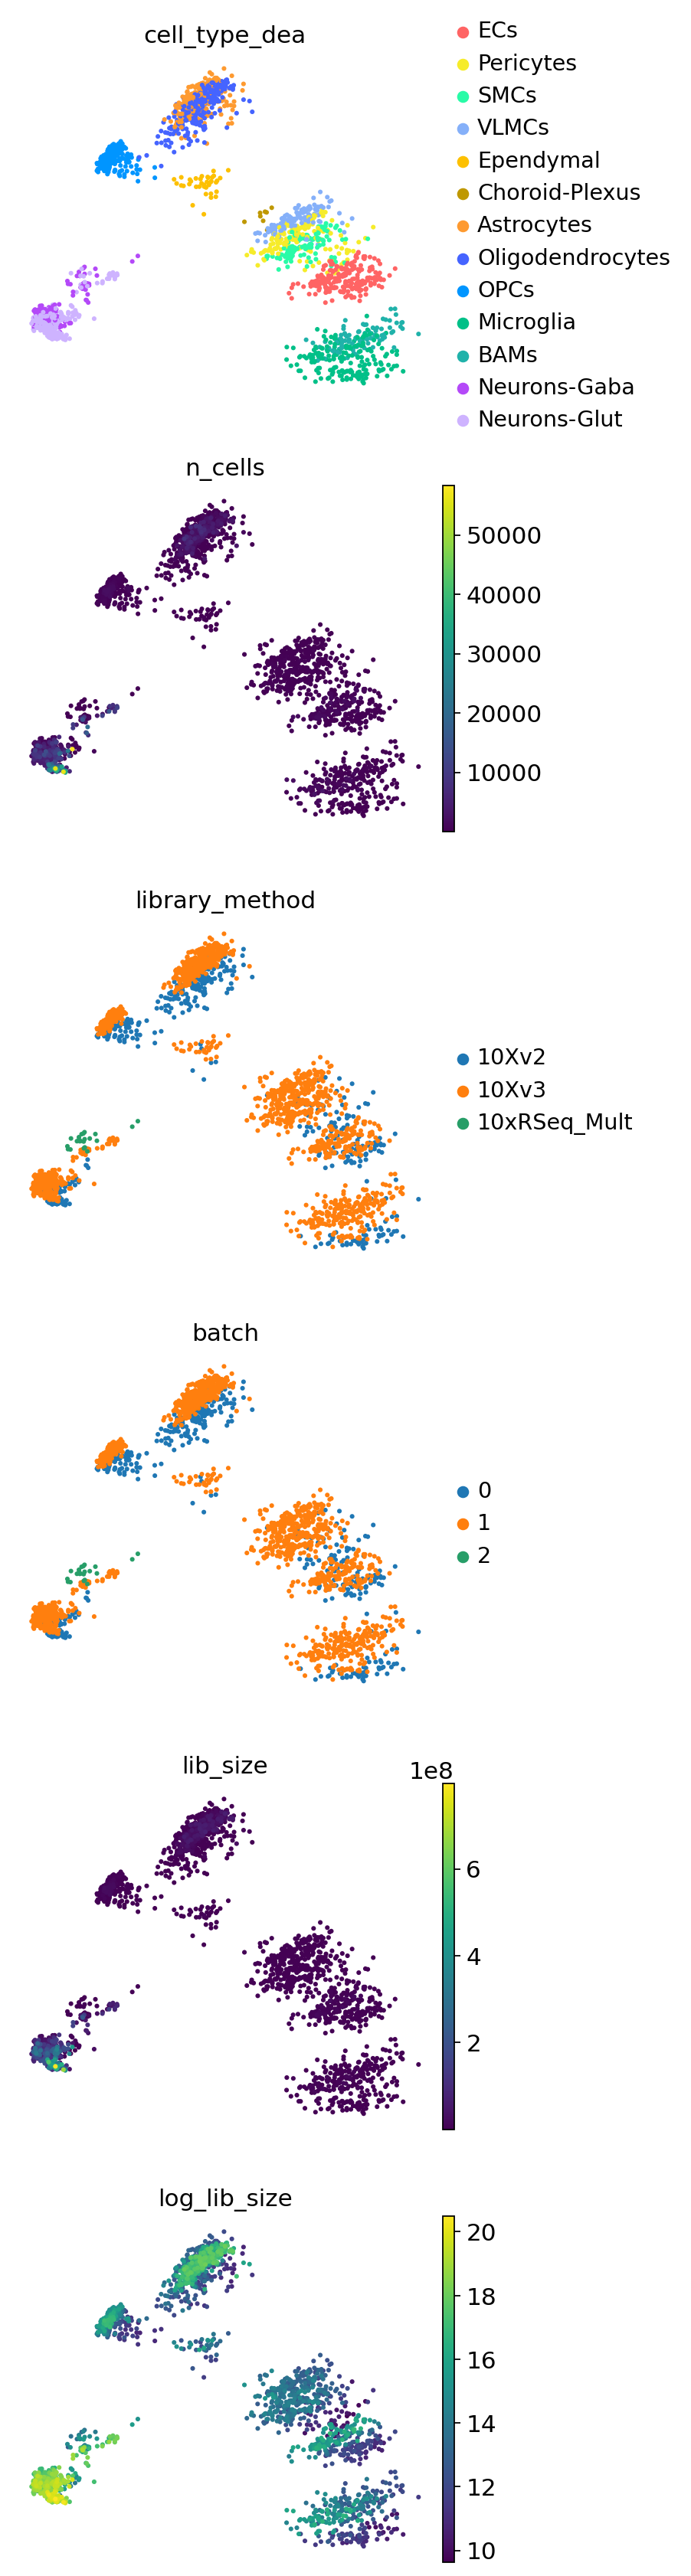

In [26]:
sc.pl.pca(
    adata_pb,
    color=adata_pb.obs.drop(columns=["celltypedea_donorid", "donor_id"]),
    ncols=1,
    size=30,
)